<a href="https://colab.research.google.com/github/DL4CV-NPTEL/2026/blob/main/notebooks/Week%206/W6_L2_Two_Stage_Detectors_RCNN_Family.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📺 [Lecture video](https://www.youtube.com/watch?v=XAZxEx8jI1w) &nbsp;|&nbsp; 📄 [Slides](https://github.com/DL4CV-NPTEL/2026/blob/main/Slides/Week%206/NPTEL_Jul24_DL4CV_W06_P01.pdf)

In [1]:
# Week 6, Lecture 2: CNN's for obj detection: Two-Stage Models
from IPython.display import HTML, display

VIDEO_ID = "XAZxEx8jI1w"

# YouTube's official embed markup. The `allow` list delegates the permissions the
# player needs; Colab renders outputs inside a nested iframe and without that
# delegation the player aborts with "Error 153".
display(HTML(f"""
<iframe width="720" height="405"
        src="https://www.youtube.com/embed/{VIDEO_ID}"
        title="YouTube video player" frameborder="0"
        allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share"
        referrerpolicy="strict-origin-when-cross-origin"
        allowfullscreen></iframe>
<p><a href="https://www.youtube.com/watch?v={VIDEO_ID}" target="_blank">Watch on YouTube</a></p>
"""))

# Week 6, Lecture 2: Two-Stage Object Detectors (The R-CNN Family)

**NPTEL Deep Learning for Computer Vision** | Prof. Vineeth N Balasubramanian, IIT Hyderabad

Companion notebook for **§6.1 CNNs for Object Detection**.

**Contents**

1. Contemporary object detection: region-proposal (two-stage) vs dense sampling (one-stage)
2. **R-CNN** (Girshick et al, CVPR 2014): Selective Search, warped crops, CNN per region, SVM + box regression
3. **Selective Search**: graph-based initial regions, hierarchical greedy grouping by colour, texture, size and fill
4. **R-CNN limitations**: multi-stage training, slow and storage heavy, 47 s per image
5. **Fast R-CNN** (Girshick, ICCV 2015): one CNN pass, RoI projection, RoI pooling, one multi-task loss
6. **RoI Pooling** and the quantization it introduces
7. The **multi-task loss** and **smooth L1** (why it resists outliers: the lecture leaves this as homework, we answer it)
8. **Faster R-CNN** (Ren et al, NeurIPS 2015): anchors and the Region Proposal Network
9. **Evaluating detectors**: IoU matching, Precision-Recall curve, Average Precision, mAP

**What you will learn**

All of it built from scratch, on one synthetic dataset.

- A procedurally generated detection dataset of coloured shapes with exact ground-truth boxes
- `box_iou`, `nms`, `roi_pool`, `smooth_l1`, box encode/decode, and `average_precision`, each checked against
  a trusted reference (torchvision / PyTorch) or against a value we compute by hand
- A **simplified Selective Search**: over-segment, then greedily merge regions up a hierarchy
- **(a)** A naive R-CNN loop: one CNN pass **per proposal**, timed
- **(b)** A Fast R-CNN: **one** CNN pass per image + RoI pooling, timed on the same data (measure the speedup)
- **(c)** A multi-task head (softmax classifier + smooth L1 box regressor) trained end to end
- **(d)** A small **RPN** with anchor boxes that replaces the hand-made proposals
- **(e)** A from-scratch **AP / PR curve** evaluation, plus COCO-style mAP over IoU 0.5:0.05:0.95

**The through-line:** every model in this lecture is the previous one with its slowest part replaced.


**How to run**

- **Self-contained.** No downloads, no pretrained weights, no pip installs. The dataset is generated by code.
- **Fast.** Everything is sized to run in a few minutes on a Colab **CPU**. GPU is used automatically if present.
- **Interactive.** Several cells end in an `ipywidgets` slider. Run the cell, then drag the slider.
- **Honest.** Every claim we make ("this is faster", "this matches torchvision", "this learns") is
  backed by a measurement or an `assert` in the notebook, not by assertion in prose.
- **Reproducible.** Seeds are set below.

## Review

Viola-Jones, HOG + SVM and OverFeat showed that detection can be posed as "classify a window,
slide it everywhere". The cost of scanning every window is what the rest of this story is about.

## Setup

In [2]:
# %matplotlib inline keeps figures as static images, which is what works inside Colab.
%matplotlib inline
import math, time, heapq
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import ipywidgets as widgets
from IPython.display import display

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 8

print('torch', torch.__version__, '| torchvision', torchvision.__version__, '| device:', device)


def show_img(ax, img, title=None):
    '''img: (3,H,W) tensor or (H,W,3) array.'''
    if torch.is_tensor(img):
        img = img.detach().cpu().numpy()
        if img.ndim == 3 and img.shape[0] == 3:
            img = img.transpose(1, 2, 0)
    ax.imshow(np.clip(img, 0, 1), interpolation='nearest')
    ax.set_xticks([]); ax.set_yticks([])
    if title:
        ax.set_title(title, fontsize=8)


def draw_boxes(ax, boxes, color='r', lw=1.6, ls='-', texts=None, alpha=1.0):
    '''boxes: (N,4) in x1,y1,x2,y2.'''
    if boxes is None or len(boxes) == 0:
        return
    b = boxes.detach().cpu().numpy() if torch.is_tensor(boxes) else np.asarray(boxes)
    for i, k in enumerate(b):
        ax.add_patch(patches.Rectangle((k[0], k[1]), k[2] - k[0], k[3] - k[1],
                                       fill=False, edgecolor=color, lw=lw, linestyle=ls, alpha=alpha))
        if texts is not None:
            ax.text(k[0], k[1] - 0.6, texts[i], color=color, fontsize=6,
                    bbox=dict(facecolor='white', alpha=0.7, pad=0.4, edgecolor='none'))

torch 2.8.0 | torchvision 0.23.0 | device: cpu


## 1. Contemporary object detection methods

The lecture splits modern detectors into two families.

**Region proposal based (two-stage)**

- **Stage 1:** propose a few hundred or thousand candidate regions that might contain an object
  (Selective Search, or later a Region Proposal Network).
- **Stage 2:** a classifier processes each candidate region, and a regressor refines its box.
- More robust in performance, but slower.
- This lecture: **R-CNN, Fast R-CNN, Faster R-CNN**.

**Dense sampling based (one-stage)**

- Integrates proposal and detection: predict directly on a **dense** grid of possible locations.
- Simple and fast, but performance historically not as good as two-stage.
- YOLO, SSD, RetinaNet: **Lecture 3**, not covered here.

**The trade-off in one line:** two-stage spends compute to look twice (propose, then verify) and buys accuracy;
one-stage looks once everywhere and buys speed.

The rest of this notebook follows that thread. We build R-CNN, notice what is slow, fix exactly
that, and repeat. Each fix is one of the three papers.

## 2. A synthetic detection dataset

We need a detection dataset with **exact** ground truth, no download, and small enough to train on a CPU.
So we draw it ourselves.

- **Canvas:** 64 x 64 RGB, light grey background, a little Gaussian noise.
- **Objects:** 1 to 3 per image, each one of 3 classes: `square`, `circle`, `triangle`.
- Each class has a base colour with **random jitter**, so colour alone is a strong but not perfect cue.
- Positions and sizes are random; we reject placements that overlap an existing object by IoU > 0.15,
  so ground-truth matching stays unambiguous.
- **Ground-truth boxes are derived from the rendered pixel mask**, so they are tight by construction.

**Class index 0 is `background`.** This is deliberate: it makes the Iverson bracket $[u \ge 1]$ in the
Fast R-CNN loss (later) mean literally "this RoI is not background".

In [3]:
IMG = 64                                    # image side in pixels
CLASS_NAMES = ['background', 'square', 'circle', 'triangle']
NUM_CLASSES = len(CLASS_NAMES)              # includes background at index 0
BASE_COLORS = np.array([[0., 0., 0.],       # background (unused)
                        [0.85, 0.15, 0.15], # square  -> red
                        [0.15, 0.70, 0.20], # circle  -> green
                        [0.20, 0.35, 0.90]])# triangle -> blue

_YS, _XS = np.mgrid[0:IMG, 0:IMG]           # pixel coordinate grids


def shape_mask(cls, cx, cy, r):
    '''Boolean pixel mask for a shape of class `cls` centred at (cx,cy) with radius r.'''
    if cls == 1:                                        # square
        return (np.abs(_XS - cx) <= r) & (np.abs(_YS - cy) <= r)
    if cls == 2:                                        # circle
        return ((_XS - cx) ** 2 + (_YS - cy) ** 2) <= r * r
    t = (_YS - (cy - r)) / (2.0 * r)                    # triangle: apex at top, base at bottom
    return (_YS >= cy - r) & (_YS <= cy + r) & (np.abs(_XS - cx) <= r * t)


def _iou_np(a, b):
    ix1, iy1 = max(a[0], b[0]), max(a[1], b[1])
    ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0.0, ix2 - ix1) * max(0.0, iy2 - iy1)
    ua = (a[2] - a[0]) * (a[3] - a[1]) + (b[2] - b[0]) * (b[3] - b[1]) - inter
    return inter / ua if ua > 0 else 0.0


def make_image(rng, max_obj=3):
    '''Returns (H,W,3) image, (N,4) boxes in x1,y1,x2,y2, (N,) class labels.'''
    img = np.full((IMG, IMG, 3), 0.82, np.float32)
    img += rng.normal(0, 0.02, img.shape).astype(np.float32)
    n = rng.integers(1, max_obj + 1)
    boxes, labels, tries = [], [], 0
    while len(boxes) < n and tries < 60:
        tries += 1
        cls = int(rng.integers(1, NUM_CLASSES))
        r = float(rng.uniform(6, 13))
        cx = float(rng.uniform(r + 1, IMG - r - 1))
        cy = float(rng.uniform(r + 1, IMG - r - 1))
        m = shape_mask(cls, cx, cy, r)
        ys, xs = np.where(m)
        if len(xs) == 0:
            continue
        box = [float(xs.min()), float(ys.min()), float(xs.max() + 1), float(ys.max() + 1)]
        if any(_iou_np(box, b) > 0.15 for b in boxes):   # keep objects well separated
            continue
        col = np.clip(BASE_COLORS[cls] + rng.uniform(-0.12, 0.12, 3), 0, 1)
        img[m] = col.astype(np.float32) + rng.normal(0, 0.02, (int(m.sum()), 3)).astype(np.float32)
        boxes.append(box); labels.append(cls)
    return np.clip(img, 0, 1), np.array(boxes, np.float32), np.array(labels, np.int64)


def make_dataset(n, seed):
    rng = np.random.default_rng(seed)
    imgs, bxs, lbs = [], [], []
    for _ in range(n):
        i, b, l = make_image(rng)
        imgs.append(i); bxs.append(torch.from_numpy(b)); lbs.append(torch.from_numpy(l))
    t = torch.from_numpy(np.stack(imgs)).permute(0, 3, 1, 2).contiguous()
    return t, bxs, lbs


N_TRAIN, N_TEST = 96, 32
tr_imgs, tr_boxes, tr_labels = make_dataset(N_TRAIN, seed=0)
te_imgs, te_boxes, te_labels = make_dataset(N_TEST, seed=777)
print('train images', tuple(tr_imgs.shape), '| test images', tuple(te_imgs.shape))
print('objects: train', sum(len(b) for b in tr_boxes), '| test', sum(len(b) for b in te_boxes))

train images (96, 3, 64, 64) | test images (32, 3, 64, 64)
objects: train 191 | test 66


Let us look at the data with its ground-truth boxes. This is what every model below has to reproduce.

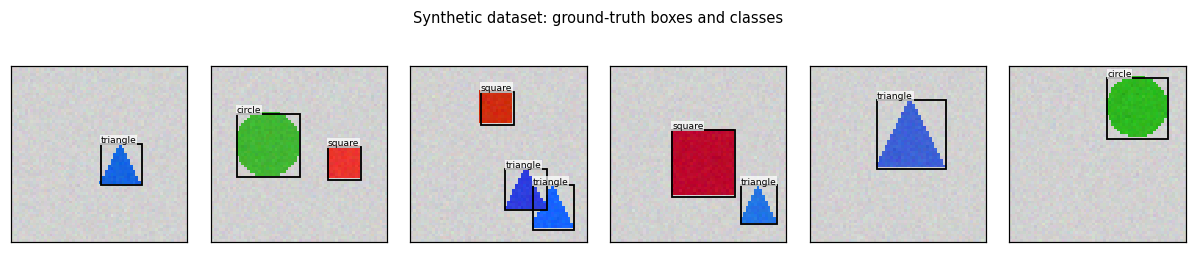

In [4]:
fig, axes = plt.subplots(1, 6, figsize=(11, 2.1))
for k, ax in enumerate(axes):
    show_img(ax, tr_imgs[k])
    draw_boxes(ax, tr_boxes[k], color='k', lw=1.2,
               texts=[CLASS_NAMES[int(c)] for c in tr_labels[k]])
fig.suptitle('Synthetic dataset: ground-truth boxes and classes', y=1.06)
plt.tight_layout(); plt.show()

## 2.1 IoU: the currency of detection

Everything in detection (matching proposals to objects, removing duplicates, scoring a detector) is built on
**Intersection over Union**:

$$\mathrm{IoU}(A,B) = \frac{|A \cap B|}{|A \cup B|} \in [0, 1]$$

- 1 means the boxes coincide, 0 means they do not touch.
- We implement it **from scratch** in a vectorised way, then check it against `torchvision.ops.box_iou`.
- This is the first of several "implement it, then prove it is right" checks. We will use the same pattern
  for RoI pooling, NMS and smooth L1.

In [5]:
def box_iou_scratch(a, b):
    '''a: (N,4), b: (M,4) in x1,y1,x2,y2. Returns (N,M) IoU matrix.'''
    area_a = (a[:, 2] - a[:, 0]).clamp(min=0) * (a[:, 3] - a[:, 1]).clamp(min=0)
    area_b = (b[:, 2] - b[:, 0]).clamp(min=0) * (b[:, 3] - b[:, 1]).clamp(min=0)
    lt = torch.max(a[:, None, :2], b[None, :, :2])       # top-left of intersection
    rb = torch.min(a[:, None, 2:], b[None, :, 2:])       # bottom-right of intersection
    wh = (rb - lt).clamp(min=0)                          # zero when the boxes miss each other
    inter = wh[..., 0] * wh[..., 1]
    union = area_a[:, None] + area_b[None, :] - inter
    return inter / union.clamp(min=1e-9)


# --- cross-check against torchvision ---
_g = np.random.default_rng(0)
_a = torch.tensor(np.stack([_g.uniform(0, 40, 50), _g.uniform(0, 40, 50),
                            _g.uniform(41, 64, 50), _g.uniform(41, 64, 50)], 1), dtype=torch.float32)
_b = torch.tensor(np.stack([_g.uniform(0, 40, 30), _g.uniform(0, 40, 30),
                            _g.uniform(41, 64, 30), _g.uniform(41, 64, 30)], 1), dtype=torch.float32)
assert torch.allclose(box_iou_scratch(_a, _b), torchvision.ops.box_iou(_a, _b), atol=1e-6)
print('box_iou_scratch matches torchvision.ops.box_iou  (max abs diff %.2e)'
      % (box_iou_scratch(_a, _b) - torchvision.ops.box_iou(_a, _b)).abs().max())

box_iou_scratch matches torchvision.ops.box_iou  (max abs diff 0.00e+00)


## 3. R-CNN (Girshick et al, CVPR 2014)

The first big win of CNNs in detection. The pipeline has two stages, exactly matching the lecture slide:

**Region proposal stage**

- Run **Selective Search** on the image, get about **2000** region proposals.

**Object detection stage**

- **Warp** each proposal to a fixed size (227 x 227 in the paper, since the CNN needs a fixed-size input).
- Push each warped crop through a CNN (AlexNet / VGG, pretrained on ImageNet) to get a feature vector.
- Classify each feature vector with **class-specific SVMs**.
- Separately, a linear **bounding-box regressor** refines the Selective Search coordinates (L2 loss).

**The critical structural fact:** the CNN runs **once per proposal**. 2000 proposals means 2000 CNN passes
per image. Hold on to that number, it is the villain of this lecture.

R-CNN's training is also a **multi-stage pipeline**: finetune the CNN, then train SVMs on cached features,
then train box regressors. Three separate trainings, with features written to disk in between.

### 3.1 Selective Search

R-CNN does not invent the proposals, it borrows them. Selective Search:

- Starts from a **graph-based image segmentation** (or mean shift) to get an initial set of small regions.
- **Hierarchically groups** them: repeatedly merge the two most similar neighbouring regions.
- Similarity combines **colour**, **texture**, **size** and **fill** (how well two regions fit into their
  joint bounding box).
- Every region that ever exists (at every level of the hierarchy) contributes its bounding box as a proposal.
- **Regions coalesce as we travel up the hierarchy**: small patches become object parts, parts become objects.

Why a hierarchy at all? Because we do not know the scale of the objects in advance. Merging from the
bottom up produces candidate boxes at **every** scale, so a good box for a small object and a good box for a
large object both appear somewhere in the tree.

> **Simplified illustration.** The cell below is **not** the real Selective Search algorithm. We replace the
> graph-based segmentation with a plain grid of 4x4 pixel cells, and use small histograms. The *idea* being
> demonstrated (over-segment, then greedily merge similar neighbours, and harvest every region's box as a
> proposal) is faithful; the implementation is deliberately tiny so it is readable.

In [6]:
CBINS, TBINS = 4, 4      # bins per channel for the colour hist / bins for the texture hist


def _grid_labels(H, W, cell):
    '''Initial over-segmentation: a regular grid of `cell` x `cell` pixel patches.'''
    nx = (W + cell - 1) // cell
    return ((np.arange(H) // cell)[:, None] * nx + (np.arange(W) // cell)[None, :]).astype(np.int64)


def _region_stats(img, labels, n):
    '''Per region: size, bbox, colour histogram, texture (gradient magnitude) histogram.'''
    g = img.mean(2)
    gx = np.zeros_like(g); gy = np.zeros_like(g)
    gx[:, 1:-1] = (g[:, 2:] - g[:, :-2]) * 0.5
    gy[1:-1, :] = (g[2:, :] - g[:-2, :]) * 0.5
    gmag = np.sqrt(gx ** 2 + gy ** 2)
    cq = np.clip((img * CBINS).astype(int), 0, CBINS - 1)
    tq = np.clip((gmag / (gmag.max() + 1e-9) * TBINS).astype(int), 0, TBINS - 1)
    ys, xs = np.mgrid[0:img.shape[0], 0:img.shape[1]]
    R = {}
    for i in range(n):
        m = labels == i
        if not m.any():
            continue
        hc = np.concatenate([np.bincount(cq[:, :, c][m], minlength=CBINS) for c in range(3)]).astype(float)
        ht = np.bincount(tq[m], minlength=TBINS).astype(float)
        R[i] = dict(size=int(m.sum()), hc=hc / hc.sum(), ht=ht / ht.sum(),
                    bbox=[int(xs[m].min()), int(ys[m].min()), int(xs[m].max()) + 1, int(ys[m].max()) + 1])
    return R


def _similarity(a, b, im_size, w=(1., 1., 1., 1.)):
    '''Selective Search similarity = colour + texture + size + fill (all in [0,1], higher = merge sooner).'''
    s_colour = np.minimum(a['hc'], b['hc']).sum() / 3.0          # histogram intersection
    s_texture = np.minimum(a['ht'], b['ht']).sum()               # histogram intersection
    s_size = 1.0 - (a['size'] + b['size']) / im_size             # prefer merging SMALL regions first
    bb = [min(a['bbox'][0], b['bbox'][0]), min(a['bbox'][1], b['bbox'][1]),
          max(a['bbox'][2], b['bbox'][2]), max(a['bbox'][3], b['bbox'][3])]
    bbsz = (bb[2] - bb[0]) * (bb[3] - bb[1])
    s_fill = 1.0 - (bbsz - a['size'] - b['size']) / im_size      # prefer regions that fill their joint box
    return w[0] * s_colour + w[1] * s_texture + w[2] * s_size + w[3] * s_fill


def _merge(a, b):
    sa, sb = a['size'], b['size']
    return dict(size=sa + sb,
                hc=(sa * a['hc'] + sb * b['hc']) / (sa + sb),    # size-weighted, as in the paper
                ht=(sa * a['ht'] + sb * b['ht']) / (sa + sb),
                bbox=[min(a['bbox'][0], b['bbox'][0]), min(a['bbox'][1], b['bbox'][1]),
                      max(a['bbox'][2], b['bbox'][2]), max(a['bbox'][3], b['bbox'][3])])


def selective_search(img, cell=4, w=(1., 1., 1., 1.)):
    '''Simplified illustration. Returns initial labels, n_init, merge sequence, proposal boxes.'''
    H, W = img.shape[:2]
    im_size = H * W
    lab0 = _grid_labels(H, W, cell)
    n0 = int(lab0.max()) + 1
    R = _region_stats(img, lab0, n0)
    adj = set()                                                   # region adjacency graph
    for i in range(H):
        for j in range(W):
            for di, dj in ((0, 1), (1, 0)):
                ii, jj = i + di, j + dj
                if ii < H and jj < W and lab0[i, j] != lab0[ii, jj]:
                    adj.add((min(lab0[i, j], lab0[ii, jj]), max(lab0[i, j], lab0[ii, jj])))
    neigh = {i: set() for i in R}
    for (i, j) in adj:
        neigh[i].add(j); neigh[j].add(i)
    heap = [(-_similarity(R[i], R[j], im_size, w), i, j) for (i, j) in adj]
    heapq.heapify(heap)
    alive = set(R.keys())
    proposals = [R[i]['bbox'] for i in R]                         # every region contributes its box
    merge_seq = []
    nxt = n0
    while heap:
        s, i, j = heapq.heappop(heap)
        if i not in alive or j not in alive:                      # stale heap entry, skip
            continue
        new = nxt; nxt += 1
        R[new] = _merge(R[i], R[j])
        alive.discard(i); alive.discard(j); alive.add(new)
        merge_seq.append((i, j, new))
        proposals.append(R[new]['bbox'])
        nb = {x for x in (neigh[i] | neigh[j]) - {i, j} if x in alive}
        neigh[new] = nb
        for x in nb:
            neigh[x].discard(i); neigh[x].discard(j); neigh[x].add(new)
            heapq.heappush(heap, (-_similarity(R[new], R[x], im_size, w), min(new, x), max(new, x)))
        if len(alive) == 1:
            break
    return lab0, n0, merge_seq, proposals


def labels_at(lab0, n0, merge_seq, k):
    '''Replay the first k merges with union-find to recover the segmentation at that level.'''
    par = np.arange(n0 + len(merge_seq))
    for (i, j, new) in merge_seq[:k]:
        par[i] = new; par[j] = new
    def find(x):
        while par[x] != x:
            par[x] = par[par[x]]; x = par[x]
        return x
    return np.array([find(x) for x in range(n0)])[lab0]


_rng = np.random.default_rng(21)
ss_img, ss_gt, ss_gtl = make_image(_rng, max_obj=3)
t0 = time.perf_counter()
ss_lab0, ss_n0, ss_seq, ss_props = selective_search(ss_img, cell=4)
print('simplified Selective Search: %.3f s | %d initial regions | %d merges | %d proposals'
      % (time.perf_counter() - t0, ss_n0, len(ss_seq), len(ss_props)))

# Does it actually find the objects? Measure, do not assume.
_P = torch.tensor(ss_props, dtype=torch.float32)
_G = torch.from_numpy(ss_gt)
_best = box_iou_scratch(_P, _G).max(0).values
print('best IoU with each ground-truth object:', [round(float(x), 3) for x in _best])
print('recall @ IoU 0.5: %.2f  (fraction of objects covered by some proposal)'
      % float((_best >= 0.5).float().mean()))

simplified Selective Search: 0.013 s | 256 initial regions | 255 merges | 511 proposals
best IoU with each ground-truth object: [0.723, 0.617, 0.635]
recall @ IoU 0.5: 1.00  (fraction of objects covered by some proposal)


Now we watch the hierarchy form. Reading left to right, neighbouring patches with similar colour and
texture merge first, the shapes emerge as single regions, and finally everything collapses into the
background. The **object-sized boxes appear at intermediate levels**, which is exactly what we harvest.

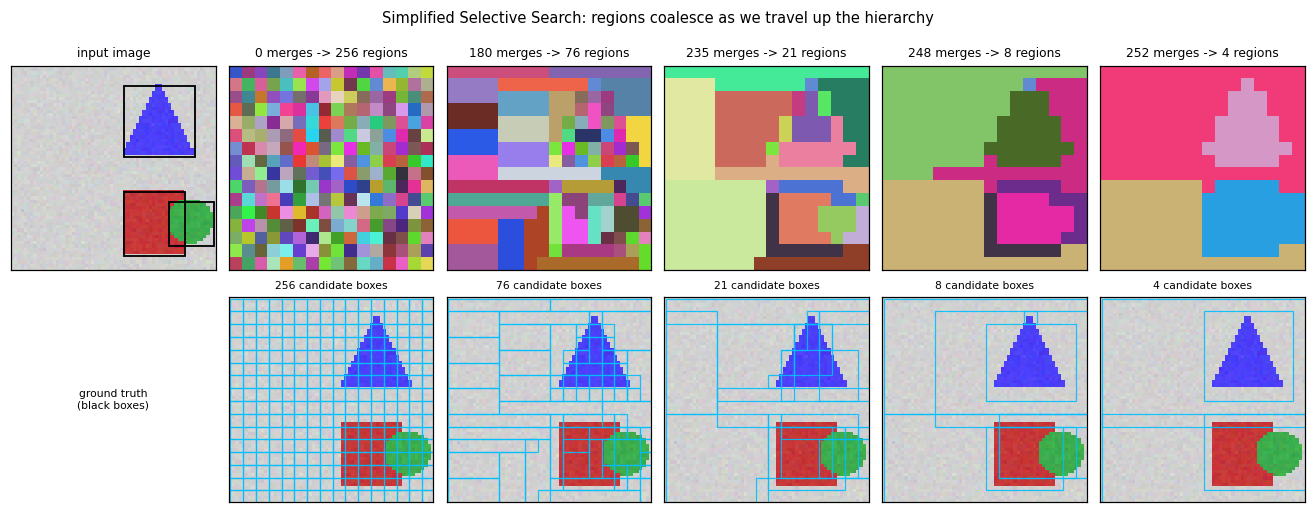

In [7]:
levels = [0, 180, 235, 248, 252]
fig, axes = plt.subplots(2, len(levels) + 1, figsize=(12, 4.7))
show_img(axes[0, 0], ss_img, 'input image')
draw_boxes(axes[0, 0], ss_gt, color='k', lw=1.2)
axes[1, 0].axis('off')
axes[1, 0].text(0.5, 0.5, 'ground truth\n(black boxes)', ha='center', va='center', fontsize=7)

rng_col = np.random.default_rng(3)
palette = rng_col.uniform(0.15, 0.95, (ss_n0 + len(ss_seq) + 1, 3))
for c, k in enumerate(levels):
    L = labels_at(ss_lab0, ss_n0, ss_seq, k)
    show_img(axes[0, c + 1], palette[L], '%d merges -> %d regions' % (k, len(np.unique(L))))
    # boxes of the regions alive at this level
    bxs = []
    for u in np.unique(L):
        m = L == u
        ys, xs = np.where(m)
        bxs.append([xs.min(), ys.min(), xs.max() + 1, ys.max() + 1])
    show_img(axes[1, c + 1], ss_img)
    draw_boxes(axes[1, c + 1], bxs, color='deepskyblue', lw=0.8, alpha=0.9)
    axes[1, c + 1].set_title('%d candidate boxes' % len(bxs), fontsize=7)
fig.suptitle('Simplified Selective Search: regions coalesce as we travel up the hierarchy', y=1.0)
plt.tight_layout(h_pad=1.6); plt.show()

**Interactive:** drag the slider through the merge hierarchy. Watch the region count fall from 256 to 1, and
watch the boxes of the surviving regions snap onto the shapes somewhere in the middle of the range.
The best-IoU readout tells you how good the best proposal is at that level.

In [8]:
def ss_explore(n_merges=240):
    L = labels_at(ss_lab0, ss_n0, ss_seq, n_merges)
    uniq = np.unique(L)
    bxs = []
    for u in uniq:
        ys, xs = np.where(L == u)
        bxs.append([xs.min(), ys.min(), xs.max() + 1, ys.max() + 1])
    B = torch.tensor(bxs, dtype=torch.float32)
    best = box_iou_scratch(B, _G).max(0).values if len(B) else torch.zeros(len(_G))

    fig, axes = plt.subplots(1, 3, figsize=(8, 2.8))
    show_img(axes[0], ss_img, 'input')
    draw_boxes(axes[0], ss_gt, color='k', lw=1.2)
    show_img(axes[1], palette[L], 'segmentation: %d regions' % len(uniq))
    show_img(axes[2], ss_img, 'boxes of live regions')
    draw_boxes(axes[2], bxs, color='deepskyblue', lw=0.9)
    draw_boxes(axes[2], ss_gt, color='k', lw=1.2, ls='--')
    fig.suptitle('after %d of %d merges | best IoU per object: %s'
                 % (n_merges, len(ss_seq), ', '.join('%.2f' % v for v in best)), y=1.04)
    plt.tight_layout(); plt.show()


widgets.interact(ss_explore,
                 n_merges=widgets.IntSlider(min=0, max=len(ss_seq), step=1, value=240,
                                            description='merges', continuous_update=False));

interactive(children=(IntSlider(value=240, continuous_update=False, description='merges', max=255), Output()),…

### 3.2 R-CNN in code: one CNN pass per proposal

Now the naive detector, built exactly as R-CNN describes it.

- A deliberately tiny CNN backbone stands in for AlexNet/VGG: 3 conv layers and 2 max-pools, so the
  **total stride is 4**. A 64 x 64 image becomes a 16 x 16 feature map.
- R-CNN **warps** every proposal to a fixed size. We warp to **16 x 16**, so that after stride 4 the backbone
  emits a **4 x 4** spatial feature per proposal. (The paper warps to 227 x 227 for AlexNet. Same idea, smaller.)
- The output for `K` proposals is a `(K, 32, 4, 4)` tensor: one fixed-size feature per proposal, ready for a head.

We time two versions, and the difference matters for honesty:

1. `rcnn_per_crop_loop`: literally one CNN call per proposal, as the slide describes.
2. `rcnn_per_crop_batched`: warp all crops, then **one batched CNN call**. This is a *generous* R-CNN: it
   removes all Python-loop overhead and lets BLAS see the whole batch. If Fast R-CNN still wins against
   *this*, the win is algorithmic and not an artefact of a slow loop.

In [9]:
class Backbone(nn.Module):
    '''Tiny stand-in for AlexNet/VGG. Two 2x2 max-pools => total stride 4.'''
    def __init__(self, c=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),   # stride 2
            nn.Conv2d(16, c, 3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),   # stride 4
            nn.Conv2d(c, c, 3, padding=1), nn.ReLU(inplace=True))
        self.stride = 4
        self.out_ch = c

    def forward(self, x):
        return self.net(x)


STRIDE = 4      # total stride of the backbone
POOL = 4        # RoI pooling output grid H = W = 4
WARP = 16       # R-CNN warps every crop to WARP x WARP, so WARP / STRIDE = POOL

_bb_demo = Backbone().to(device).eval()
print('backbone stride', _bb_demo.stride, '| feature map for a 64x64 image:',
      tuple(_bb_demo(torch.zeros(1, 3, IMG, IMG, device=device)).shape))


@torch.no_grad()
def rcnn_per_crop_loop(img, props, bb):
    '''Literal R-CNN: warp each proposal and run the CNN once PER proposal.'''
    outs = []
    for k in range(props.shape[0]):
        x1, y1, x2, y2 = [int(v) for v in props[k]]
        x2, y2 = max(x2, x1 + 1), max(y2, y1 + 1)
        crop = img[:, :, y1:y2, x1:x2]                                   # crop in IMAGE space
        warped = F.interpolate(crop, size=(WARP, WARP), mode='bilinear', align_corners=False)
        outs.append(bb(warped))                                          # one CNN call per proposal
    return torch.cat(outs, 0)


@torch.no_grad()
def rcnn_per_crop_batched(img, props, bb):
    '''Generous R-CNN: same maths, but all warped crops go through the CNN in ONE batched call.'''
    crops = []
    for k in range(props.shape[0]):
        x1, y1, x2, y2 = [int(v) for v in props[k]]
        x2, y2 = max(x2, x1 + 1), max(y2, y1 + 1)
        crops.append(F.interpolate(img[:, :, y1:y2, x1:x2], size=(WARP, WARP),
                                   mode='bilinear', align_corners=False))
    return bb(torch.cat(crops, 0))


def random_boxes(n, rng, lo=8, hi=28):
    x1 = rng.uniform(0, IMG - 9, n); y1 = rng.uniform(0, IMG - 9, n)
    w = rng.uniform(lo, hi, n); h = rng.uniform(lo, hi, n)
    b = np.stack([x1, y1, np.minimum(x1 + w, IMG), np.minimum(y1 + h, IMG)], 1)
    return torch.tensor(b, dtype=torch.float32)


_demo_img = te_imgs[:1].to(device)
_demo_props = random_boxes(200, np.random.default_rng(3)).to(device)
_f_loop = rcnn_per_crop_loop(_demo_img, _demo_props, _bb_demo)
print('200 proposals -> per-crop features', tuple(_f_loop.shape),
      '(one fixed-size %dx%d feature per proposal)' % (POOL, POOL))

backbone stride 4 | feature map for a 64x64 image: (1, 32, 16, 16)
200 proposals -> per-crop features (200, 32, 4, 4) (one fixed-size 4x4 feature per proposal)


Let us time the literal R-CNN on a single 64 x 64 image, and extrapolate to the real thing.

In [10]:
def bench(fn, *args, repeats=5):
    fn(*args)                                     # warm-up (kernel selection, caches)
    ts = []
    for _ in range(repeats):
        t0 = time.perf_counter(); fn(*args); ts.append(time.perf_counter() - t0)
    return float(np.median(ts))


t_loop_200 = bench(rcnn_per_crop_loop, _demo_img, _demo_props, _bb_demo)
print('R-CNN, 200 proposals on ONE 64x64 image: %.1f ms  (%.3f ms per proposal)'
      % (t_loop_200 * 1e3, t_loop_200 * 1e3 / 200))
print('Extrapolated to R-CNN\'s real workload (2000 proposals): %.2f s per image'
      % (t_loop_200 / 200 * 2000))
print()
print('And that is with a 6-layer toy CNN on 16x16 crops.')
print('R-CNN used VGG-16 on 227x227 crops: hence the 47 s/image the lecture quotes.')

R-CNN, 200 proposals on ONE 64x64 image: 46.6 ms  (0.233 ms per proposal)
Extrapolated to R-CNN's real workload (2000 proposals): 0.47 s per image

And that is with a 6-layer toy CNN on 16x16 crops.
R-CNN used VGG-16 on 227x227 crops: hence the 47 s/image the lecture quotes.


## 4. R-CNN: limitations

The lecture lists three, and we have just felt the third one:

- **Multi-stage training pipeline.** Finetune the CNN, then train SVMs, then train box regressors.
  Three disjoint objectives, nothing is trained end to end.
- **Feature extraction is slow and storage heavy.** Features for every proposal of every image are written
  to disk to train the SVMs: PASCAL VOC07 (5k images) costs about **2.5 GPU-days** and **hundreds of GB**.
- **Test time is 47 s per image.** Unusable in practice.

**Where does the time actually go?** Not into the 2000 warps, and not into the SVMs. It goes into
**2000 CNN passes per image**. And here is the observation that unlocks the next paper:

> The 2000 proposals of an image are 2000 **overlapping** windows of the **same** image. R-CNN recomputes
> convolutional features on the same pixels over and over again.

Convolution is translation-equivariant: the features of a sub-window of the image are (almost) the
corresponding sub-window of the features of the whole image. So compute the feature map **once**, and
just **look up** each proposal's slice of it. That is Fast R-CNN.

## 5. Fast R-CNN (Girshick, ICCV 2015)

Two changes to R-CNN, both aimed at things we just complained about:

- **One CNN pass over the whole image.** Instead of pushing each region proposal through the CNN, extract
  each proposal's features **directly from the shared feature map**. This kills the 2000x redundancy.
- **One multi-task loss.** Classification and box regression train together, in one network, in one stage.
  No SVMs, no cached features on disk, no three-stage pipeline.

Two mechanisms make the first change work: **RoI projection** and **RoI pooling**.

### 5.1 RoI projection

A proposal is given in **image** coordinates, but we now want to index the **feature map**. Since the
backbone has total stride $s$, a pixel at image coordinate $x$ lands at feature coordinate $x/s$.
So we project the box:

$$(x_1, y_1, x_2, y_2)_{\text{image}} \;\longrightarrow\; \left(\tfrac{x_1}{s}, \tfrac{y_1}{s}, \tfrac{x_2}{s}, \tfrac{y_2}{s}\right)_{\text{feature}}$$

- The lecture's figure walks a 14 x 14 input through a 3x3 stride-1 conv (-> 12 x 12) and a 2x2 max-pool
  (-> 6 x 6), and carries the RoI along with it. Our backbone has stride 4, so we simply divide by 4.
- **No pixels are cropped and no CNN is re-run.** Projection is arithmetic on 4 numbers.
- The projected box has **fractional** coordinates. The feature map has integer cells. Reconciling those two
  facts is where **quantization** enters, and it is the subject of the next section.

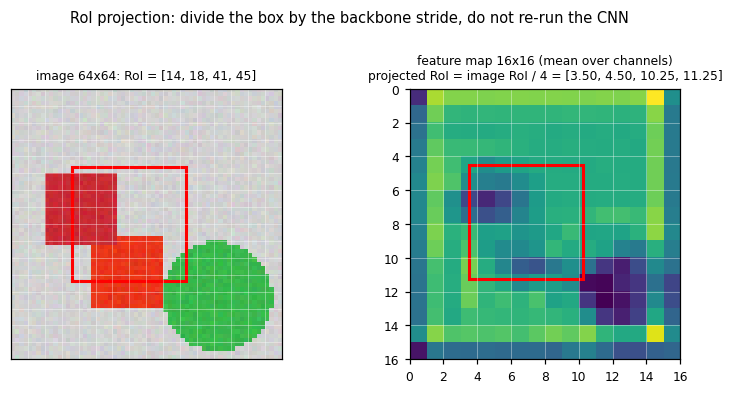

Note the projected coordinates are fractional: [3.5, 4.5, 10.25, 11.25]
The feature map only has integer cells. Something has to give -> quantization.


In [11]:
_proj_img = te_imgs[3:4].to(device)
with torch.no_grad():
    _proj_fm = _bb_demo(_proj_img)
_roi = torch.tensor([[14., 18., 41., 45.]])                 # a box in image coordinates
_roi_f = _roi / STRIDE                                      # the SAME box in feature coordinates

fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.4))
show_img(axes[0], _proj_img[0], 'image (64 x 64), RoI in image coords')
for k in range(0, IMG + 1, STRIDE):                          # cell boundaries of the feature map
    axes[0].axhline(k - 0.5, color='w', lw=0.35, alpha=0.7)
    axes[0].axvline(k - 0.5, color='w', lw=0.35, alpha=0.7)
draw_boxes(axes[0], _roi, color='red', lw=2)
axes[0].set_title('image 64x64: RoI = [%.0f, %.0f, %.0f, %.0f]' % tuple(_roi[0]), fontsize=8)

fmv = _proj_fm[0].mean(0).detach().cpu().numpy()
axes[1].imshow(fmv, cmap='viridis', interpolation='nearest', extent=[0, fmv.shape[1], fmv.shape[0], 0])
axes[1].add_patch(patches.Rectangle((_roi_f[0, 0], _roi_f[0, 1]),
                                    _roi_f[0, 2] - _roi_f[0, 0], _roi_f[0, 3] - _roi_f[0, 1],
                                    fill=False, edgecolor='red', lw=2))
axes[1].set_xticks(range(0, fmv.shape[1] + 1, 2)); axes[1].set_yticks(range(0, fmv.shape[0] + 1, 2))
axes[1].grid(color='w', lw=0.35, alpha=0.7)
axes[1].set_title('feature map 16x16 (mean over channels)\nprojected RoI = image RoI / %d = [%.2f, %.2f, %.2f, %.2f]'
                  % (STRIDE, *_roi_f[0]), fontsize=8)
fig.suptitle('RoI projection: divide the box by the backbone stride, do not re-run the CNN', y=1.02)
plt.tight_layout(); plt.show()
print('Note the projected coordinates are fractional: %s' % _roi_f[0].tolist())
print('The feature map only has integer cells. Something has to give -> quantization.')

### 5.2 RoI Pooling

The head is a fully connected network, so it needs a **fixed-size** input. But RoIs come at all scales.
We need a scale-invariant pooling. The lecture states it exactly:

> Given an RoI of size $h \times w$, RoI Pooling converts this region into an $H \times W$ grid of
> subwindows, each of size approximately $h/H \times w/W$, and **max-pools** within each subwindow.

So an 8 x 8 RoI and a 4 x 6 RoI both come out as (say) 2 x 2. The RoI's size is absorbed by the bin size.

**Where the quantization happens (twice):**

1. The **projected RoI** is rounded to integer feature cells.
2. The **bin boundaries** inside the RoI are floor/ceil'ed to integer cells.

Both roundings shift the pooled region by up to half a feature cell, which is `stride/2 = 2` image pixels
here. Remember this, we will measure what it costs at the end of the notebook.

We implement RoI pooling **from scratch**, faithfully reproducing torchvision's kernel, then prove the two
agree.

In [12]:
def roi_pool_scratch(features, rois, output_size, spatial_scale):
    '''From-scratch RoI pooling.

    features      : (N, C, Hf, Wf) shared feature map
    rois          : (K, 5) rows of (batch_index, x1, y1, x2, y2) in IMAGE coordinates
    output_size   : (H, W) fixed output grid
    spatial_scale : 1 / backbone_stride, i.e. the image -> feature scale factor
    returns       : (K, C, H, W)
    '''
    N, C, Hf, Wf = features.shape
    K = rois.shape[0]
    H_out, W_out = output_size
    out = features.new_zeros((K, C, H_out, W_out))

    for k in range(K):
        b = int(rois[k, 0])
        # ---- QUANTIZATION #1: project to feature coords, then round to integer cells.
        # We use floor(x + 0.5) = "round half away from zero", which is what C++ std::round does
        # inside torchvision. (torch.round does banker's rounding and would NOT match.)
        x1 = int(math.floor(float(rois[k, 1]) * spatial_scale + 0.5))
        y1 = int(math.floor(float(rois[k, 2]) * spatial_scale + 0.5))
        x2 = int(math.floor(float(rois[k, 3]) * spatial_scale + 0.5))
        y2 = int(math.floor(float(rois[k, 4]) * spatial_scale + 0.5))

        roi_w = max(x2 - x1 + 1, 1)          # malformed RoIs are forced to be 1x1
        roi_h = max(y2 - y1 + 1, 1)
        bin_h = roi_h / H_out                # subwindow of size approx h/H x w/W
        bin_w = roi_w / W_out

        for i in range(H_out):
            for j in range(W_out):
                # ---- QUANTIZATION #2: bin boundaries snap to integer cells.
                hs = int(math.floor(i * bin_h)); he = int(math.ceil((i + 1) * bin_h))
                ws = int(math.floor(j * bin_w)); we = int(math.ceil((j + 1) * bin_w))
                hs = min(max(hs + y1, 0), Hf); he = min(max(he + y1, 0), Hf)   # offset and clip
                ws = min(max(ws + x1, 0), Wf); we = min(max(we + x1, 0), Wf)
                if he <= hs or we <= ws:
                    continue                 # empty bin stays 0, matching torchvision
                out[k, :, i, j] = features[b, :, hs:he, ws:we].amax(dim=(1, 2))   # MAX pool
    return out

**The check.** We compare against `torchvision.ops.roi_pool` on 200 random RoIs across several output sizes.
We deliberately include RoIs whose projected coordinates land exactly on `.5` (with stride 4, any coordinate
of the form `4k + 2` does), because that is precisely where a wrong rounding rule shows up.

If this assert passes, our implementation *is* RoI pooling, not an approximation of it.

In [13]:
_g = np.random.default_rng(1)
_r = []
for _ in range(200):
    b = int(_g.integers(0, te_imgs.shape[0] if te_imgs.shape[0] < 8 else 8))
    x1 = float(_g.integers(0, 55)); y1 = float(_g.integers(0, 55))
    _r.append([b, x1, y1, min(x1 + float(_g.integers(2, 20)), 64.), min(y1 + float(_g.integers(2, 20)), 64.)])
_rois_t = torch.tensor(_r, dtype=torch.float32)
# adversarial: coords of the form 4k+2 project to exactly *.5 in feature space
_rois_t[0] = torch.tensor([0., 2., 6., 10., 14.])
_rois_t[1] = torch.tensor([1., 6., 2., 22., 26.])
_rois_t[2] = torch.tensor([2., 10., 10., 30., 30.])

with torch.no_grad():
    _fm8 = _bb_demo(te_imgs[:8].to(device))
_rois_t = _rois_t.to(device)

for osz in [(4, 4), (2, 2), (3, 5), (1, 1), (6, 6), (7, 2)]:
    mine = roi_pool_scratch(_fm8, _rois_t, osz, 1.0 / STRIDE)
    ref = torchvision.ops.roi_pool(_fm8, _rois_t, output_size=osz, spatial_scale=1.0 / STRIDE)
    assert torch.allclose(mine, ref), 'mismatch at output size %s' % (osz,)
    print('output %-6s max abs diff vs torchvision.ops.roi_pool: %.1e   OK' % (str(osz), (mine - ref).abs().max()))

print('\nroi_pool_scratch reproduces torchvision.ops.roi_pool exactly (200 RoIs, 6 output sizes).')
print('From here we call the fast C++ kernel, having earned the right to trust it.')

output (4, 4) max abs diff vs torchvision.ops.roi_pool: 0.0e+00   OK
output (2, 2) max abs diff vs torchvision.ops.roi_pool: 0.0e+00   OK
output (3, 5) max abs diff vs torchvision.ops.roi_pool: 0.0e+00   OK
output (1, 1) max abs diff vs torchvision.ops.roi_pool: 0.0e+00   OK


output (6, 6) max abs diff vs torchvision.ops.roi_pool: 0.0e+00   OK
output (7, 2) max abs diff vs torchvision.ops.roi_pool: 0.0e+00   OK

roi_pool_scratch reproduces torchvision.ops.roi_pool exactly (200 RoIs, 6 output sizes).
From here we call the fast C++ kernel, having earned the right to trust it.


### RoI pooling, made visible

Drag the sliders. The right panel shows the feature map with:

- the **exact** projected RoI (cyan, dashed): `image_box / stride`, fractional
- the **quantized** RoI (red, solid): what RoI pooling actually pools from
- the **red shading**: the quantization error, i.e. feature cells that are wrongly included or excluded
- the **white lines**: the H x W bin boundaries, each bin max-pooled to one output value

Things worth discovering:

- Move the RoI by 1 or 2 pixels and watch the **output not change at all**. Sub-stride detail is invisible.
- The reported error is up to half a feature cell per edge = **`stride/2` = 2 image pixels**.
- Make H, W larger than the RoI's size in cells: bins start to **overlap** rather than tile.

In [14]:
def roi_pool_demo(x1=14, y1=18, w=27, h=27, H=4, W=4):
    x2, y2 = min(x1 + w, IMG), min(y1 + h, IMG)
    roi = torch.tensor([[0., float(x1), float(y1), float(x2), float(y2)]], device=device)
    ss = 1.0 / STRIDE
    ex = np.array([x1 * ss, y1 * ss, x2 * ss, y2 * ss])                    # exact projection
    q = np.array([math.floor(v * ss + 0.5) for v in [x1, y1, x2, y2]])      # quantized projection

    pooled = roi_pool_scratch(_proj_fm, roi, (H, W), ss)[0].mean(0).detach().cpu().numpy()
    fmv = _proj_fm[0].mean(0).detach().cpu().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(9.5, 3.1))
    show_img(axes[0], _proj_img[0], 'image + RoI')
    for k in range(0, IMG + 1, STRIDE):
        axes[0].axhline(k - 0.5, color='w', lw=0.3, alpha=0.6); axes[0].axvline(k - 0.5, color='w', lw=0.3, alpha=0.6)
    draw_boxes(axes[0], roi[:, 1:].cpu(), color='red', lw=1.8)

    ax = axes[1]
    ax.imshow(fmv, cmap='viridis', interpolation='nearest', extent=[0, fmv.shape[1], fmv.shape[0], 0])
    # quantized region actually pooled: cells [q0, q2] x [q1, q3] inclusive
    qw, qh = max(q[2] - q[0] + 1, 1), max(q[3] - q[1] + 1, 1)
    ax.add_patch(patches.Rectangle((q[0], q[1]), qw, qh, facecolor='red', alpha=0.22, edgecolor='red', lw=1.8))
    ax.add_patch(patches.Rectangle((ex[0], ex[1]), ex[2] - ex[0], ex[3] - ex[1],
                                   fill=False, edgecolor='cyan', lw=1.6, ls='--'))
    for i in range(1, H):                                    # bin boundaries
        ax.axhline(q[1] + i * qh / H, xmin=q[0] / fmv.shape[1], xmax=(q[0] + qw) / fmv.shape[1], color='w', lw=1)
    for j in range(1, W):
        ax.axvline(q[0] + j * qw / W, ymin=1 - (q[1] + qh) / fmv.shape[0], ymax=1 - q[1] / fmv.shape[0], color='w', lw=1)
    ax.set_xticks(range(0, fmv.shape[1] + 1, 4)); ax.set_yticks(range(0, fmv.shape[0] + 1, 4))
    ax.grid(color='w', lw=0.25, alpha=0.5)
    ax.set_title('feature map: exact (cyan) vs pooled (red)\nbins %d x %d of size %.2f x %.2f cells'
                 % (H, W, qh / H, qw / W), fontsize=7)

    axes[2].imshow(pooled, cmap='viridis', interpolation='nearest')
    axes[2].set_xticks([]); axes[2].set_yticks([])
    axes[2].set_title('RoI pooling output: %d x %d\n(fixed size, whatever the RoI)' % (H, W), fontsize=7)

    err = np.abs(ex - q)
    fig.suptitle('quantization error per edge: %s cells = %s image px'
                 % (np.round(err, 2).tolist(), np.round(err * STRIDE, 2).tolist()), y=1.06, fontsize=8)
    plt.tight_layout(); plt.show()


widgets.interact(roi_pool_demo,
                 x1=widgets.IntSlider(min=0, max=50, step=1, value=14, description='RoI x1', continuous_update=False),
                 y1=widgets.IntSlider(min=0, max=50, step=1, value=18, description='RoI y1', continuous_update=False),
                 w=widgets.IntSlider(min=4, max=40, step=1, value=27, description='RoI w', continuous_update=False),
                 h=widgets.IntSlider(min=4, max=40, step=1, value=27, description='RoI h', continuous_update=False),
                 H=widgets.IntSlider(min=1, max=8, step=1, value=4, description='pool H', continuous_update=False),
                 W=widgets.IntSlider(min=1, max=8, step=1, value=4, description='pool W', continuous_update=False));

interactive(children=(IntSlider(value=14, continuous_update=False, description='RoI x1', max=50), IntSlider(va…

### 5.3 The payoff: measuring the speedup

Now we run all three implementations on **the same image with the same proposals** and time them.

- **R-CNN (per-crop loop):** `P` CNN calls on 16 x 16 crops.
- **R-CNN (batched crops):** 1 CNN call on a `(P, 3, 16, 16)` batch. The generous version.
- **Fast R-CNN (shared):** 1 CNN call on the `(1, 3, 64, 64)` image, then `P` RoI pools.

**The asymptotic argument, before we measure.** Count the pixels the convolutions touch:

| | conv work | at P = 200 | at P = 2000 (real R-CNN) |
|---|---|---|---|
| R-CNN | $P \times 16 \times 16$ | 51,200 px | 512,000 px |
| Fast R-CNN | $1 \times 64 \times 64$ | 4,096 px | 4,096 px |

R-CNN's conv cost grows **linearly in the number of proposals**; Fast R-CNN's is **constant**. RoI pooling
is a handful of comparisons per proposal, which is nothing next to a conv stack. Note the two paths are
**not** numerically identical (a warped crop through the CNN is a different function from pooling the shared
map). They produce the **same shape**, feed the **same head**, and Fast R-CNN's claim is that the shared
features are just as good. What follows is the cost.

all three paths return (200, 32, 4, 4) -> same head fits all

R-CNN (per-crop loop)                 46.02 ms
R-CNN (batched crops)                  5.64 ms
Fast R-CNN (shared + RoI pool)         0.62 ms

speedup vs per-crop loop  : 74.7x
speedup vs batched crops  : 9.2x  <- the purely algorithmic win


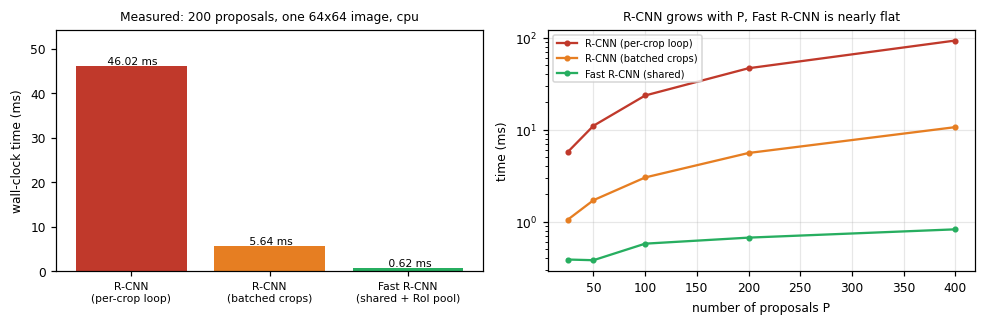

In [15]:
@torch.no_grad()
def fast_rcnn_shared(img, props, bb):
    '''Fast R-CNN: ONE CNN pass over the image, then RoI-pool every proposal off the shared map.'''
    fm = bb(img)                                                          # <- the one and only CNN pass
    rois = torch.cat([torch.zeros(props.shape[0], 1, device=props.device), props], 1)
    return torchvision.ops.roi_pool(fm, rois, output_size=(POOL, POOL), spatial_scale=1.0 / bb.stride)


P_BENCH = 200
props_b = random_boxes(P_BENCH, np.random.default_rng(3)).to(device)

t_loop = bench(rcnn_per_crop_loop, _demo_img, props_b, _bb_demo)
t_batch = bench(rcnn_per_crop_batched, _demo_img, props_b, _bb_demo)
t_shared = bench(fast_rcnn_shared, _demo_img, props_b, _bb_demo)

# sanity: all three really do produce the same fixed-size feature tensor
assert rcnn_per_crop_loop(_demo_img, props_b, _bb_demo).shape == fast_rcnn_shared(_demo_img, props_b, _bb_demo).shape
print('all three paths return', tuple(fast_rcnn_shared(_demo_img, props_b, _bb_demo).shape), '-> same head fits all\n')

names = ['R-CNN\n(per-crop loop)', 'R-CNN\n(batched crops)', 'Fast R-CNN\n(shared + RoI pool)']
times = [t_loop * 1e3, t_batch * 1e3, t_shared * 1e3]
for n, t in zip(names, times):
    print('%-34s %8.2f ms' % (n.replace('\n', ' '), t))
print()
print('speedup vs per-crop loop  : %.1fx' % (t_loop / t_shared))
print('speedup vs batched crops  : %.1fx  <- the purely algorithmic win' % (t_batch / t_shared))

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
cols = ['#c0392b', '#e67e22', '#27ae60']
bars = axes[0].bar(range(3), times, color=cols)
axes[0].set_xticks(range(3)); axes[0].set_xticklabels(names, fontsize=7)
axes[0].set_ylabel('wall-clock time (ms)')
axes[0].set_title('Measured: %d proposals, one 64x64 image, %s' % (P_BENCH, str(device)), fontsize=8)
for b, t in zip(bars, times):
    axes[0].text(b.get_x() + b.get_width() / 2, t, ' %.2f ms' % t, ha='center', va='bottom', fontsize=7)
axes[0].set_ylim(0, max(times) * 1.18)

# scaling with the number of proposals
Ps = [25, 50, 100, 200, 400]
curves = {n: [] for n in ['R-CNN (per-crop loop)', 'R-CNN (batched crops)', 'Fast R-CNN (shared)']}
for P in Ps:
    pr = random_boxes(P, np.random.default_rng(3)).to(device)
    curves['R-CNN (per-crop loop)'].append(bench(rcnn_per_crop_loop, _demo_img, pr, _bb_demo, repeats=3) * 1e3)
    curves['R-CNN (batched crops)'].append(bench(rcnn_per_crop_batched, _demo_img, pr, _bb_demo, repeats=3) * 1e3)
    curves['Fast R-CNN (shared)'].append(bench(fast_rcnn_shared, _demo_img, pr, _bb_demo, repeats=3) * 1e3)
for (k, v), c in zip(curves.items(), cols):
    axes[1].plot(Ps, v, 'o-', color=c, label=k, ms=3)
axes[1].set_xlabel('number of proposals P'); axes[1].set_ylabel('time (ms)')
axes[1].set_yscale('log'); axes[1].legend(fontsize=6.5); axes[1].grid(alpha=0.3)
axes[1].set_title('R-CNN grows with P, Fast R-CNN is nearly flat', fontsize=8)
plt.tight_layout(); plt.show()

**Interactive:** move the proposal count and watch the gap open up. At very small `P` the shared backbone
has to pay for a full image pass and barely wins; as `P` grows, R-CNN's linear cost takes over. This is the
whole point: real detectors want **thousands** of proposals.

In [16]:
def timing_demo(P=200):
    pr = random_boxes(P, np.random.default_rng(3)).to(device)
    tl = bench(rcnn_per_crop_loop, _demo_img, pr, _bb_demo, repeats=3) * 1e3
    tb = bench(rcnn_per_crop_batched, _demo_img, pr, _bb_demo, repeats=3) * 1e3
    ts = bench(fast_rcnn_shared, _demo_img, pr, _bb_demo, repeats=3) * 1e3
    fig, ax = plt.subplots(figsize=(5.2, 2.6))
    bars = ax.bar(range(3), [tl, tb, ts], color=cols)
    ax.set_xticks(range(3)); ax.set_xticklabels(['R-CNN\nper-crop loop', 'R-CNN\nbatched', 'Fast R-CNN\nshared'], fontsize=7)
    ax.set_ylabel('ms'); ax.set_ylim(0, max(tl, tb, ts) * 1.2)
    for b, t in zip(bars, [tl, tb, ts]):
        ax.text(b.get_x() + b.get_width() / 2, t, ' %.2f' % t, ha='center', va='bottom', fontsize=7)
    ax.set_title('P = %d proposals | conv pixels: R-CNN %d vs Fast R-CNN %d\nspeedup %.1fx (loop), %.1fx (batched)'
                 % (P, P * WARP * WARP, IMG * IMG, tl / ts, tb / ts), fontsize=8)
    plt.tight_layout(); plt.show()


widgets.interact(timing_demo,
                 P=widgets.IntSlider(min=10, max=400, step=10, value=200,
                                     description='proposals', continuous_update=False));

interactive(children=(IntSlider(value=200, continuous_update=False, description='proposals', max=400, min=10, …

### 5.4 The multi-task loss

R-CNN trained three things separately. Fast R-CNN trains **one network with one loss**. Following the lecture:

- $u$ is the **true class**, $v = (v_x, v_y, v_w, v_h)$ the ground-truth box regression target
- $p$ is the predicted class probability vector, $t^u = (t^u_x, t^u_y, t^u_w, t^u_h)$ the predicted box
  offsets **for the true class** $u$

$$L(p, u, t^u, v) = L_{\text{cls}}(p, u) + \lambda \, [u \ge 1] \, L_{\text{loc}}(t^u, v)$$

with

$$L_{\text{cls}}(p, u) = -\log p_u \qquad\text{(plain log loss)}$$

$$L_{\text{loc}}(t^u, v) = \sum_{i \in \{x, y, w, h\}} \mathrm{smooth}_{L_1}(t^u_i - v_i)$$

$$\mathrm{smooth}_{L_1}(x) = \begin{cases} 0.5 x^2 & \text{if } |x| < 1 \\ |x| - 0.5 & \text{otherwise}\end{cases}$$

Reading the formula:

- **$[u \ge 1]$ is the Iverson bracket**: 1 when the RoI is a real object, 0 when it is background. Background
  RoIs have no box to regress to, so they contribute **classification loss only**. (This is why we made class
  index 0 = background.)
- **$t^u$ is class-specific**: the network predicts a separate 4-vector of offsets per class, and the loss uses
  only the row for the true class $u$. Our head outputs `NUM_CLASSES x 4` and indexes row $u$; the background
  row exists for indexing convenience and is never used, precisely because of $[u \ge 1]$.
- **$\lambda$ balances the two tasks.** We will measure what it actually does later, once we have a metric.

### Smooth L1 vs L2: the lecture's homework, answered

> *"Smooth L1 loss is less sensitive to outliers than L2 loss. Why? Homework!"*

The answer is in the **gradient**, not the loss value. For a residual $x$:

$$\frac{d}{dx}\left(\tfrac{1}{2}x^2\right) = x \qquad\qquad \frac{d}{dx}\,\mathrm{smooth}_{L_1}(x) = \begin{cases} x & |x| < 1 \\ \mathrm{sign}(x) & \text{otherwise}\end{cases}$$

- **L2's gradient is unbounded and grows linearly with the error.** A badly-placed proposal with a residual of
  20 contributes a gradient of magnitude 20, which is 20x that of a residual of 1. One bad RoI can dominate the
  whole minibatch update and blow up training. (R-CNN used L2 for its box regressor and needed care to stabilise it.)
- **Smooth L1's gradient saturates at magnitude 1.** An outlier can never contribute more than a well-fit
  example does. It still says "move that way", but it cannot shout.
- Near 0 it stays **quadratic**, so the gradient tapers smoothly to 0 and the loss is differentiable at the
  origin (unlike pure L1, whose gradient jumps from -1 to +1 and never lets the residual settle).

Smooth L1 is therefore "L2 where it matters (small errors), L1 where it is dangerous (large errors)".
We implement it and check against PyTorch's `F.smooth_l1_loss`.

In [17]:
def smooth_l1_scratch(x, beta=1.0):
    '''beta generalises the lecture's threshold of 1: quadratic for |x| < beta, linear beyond.'''
    ax = x.abs()
    return torch.where(ax < beta, 0.5 * x * x / beta, ax - 0.5 * beta)


def smooth_l1_grad(x, beta=1.0):
    return torch.where(x.abs() < beta, x / beta, torch.sign(x))


_d = torch.linspace(-6, 6, 241)
for _b in [0.5, 1.0, 2.0]:
    _ref = F.smooth_l1_loss(_d, torch.zeros_like(_d), beta=_b, reduction='none')
    assert torch.allclose(smooth_l1_scratch(_d, _b), _ref, atol=1e-7)
    # and check our analytic gradient against autograd
    _x = _d.clone().requires_grad_(True)
    F.smooth_l1_loss(_x, torch.zeros_like(_x), beta=_b, reduction='sum').backward()
    assert torch.allclose(smooth_l1_grad(_d, _b), _x.grad, atol=1e-6)
print('smooth_l1_scratch matches F.smooth_l1_loss, and smooth_l1_grad matches autograd (beta = 0.5, 1, 2). OK')

smooth_l1_scratch matches F.smooth_l1_loss, and smooth_l1_grad matches autograd (beta = 0.5, 1, 2). OK


The plot below is the whole argument. Left: the losses (smooth L1 grows linearly, L2 parabolically).
**Right: the gradients, which is what training actually sees.**

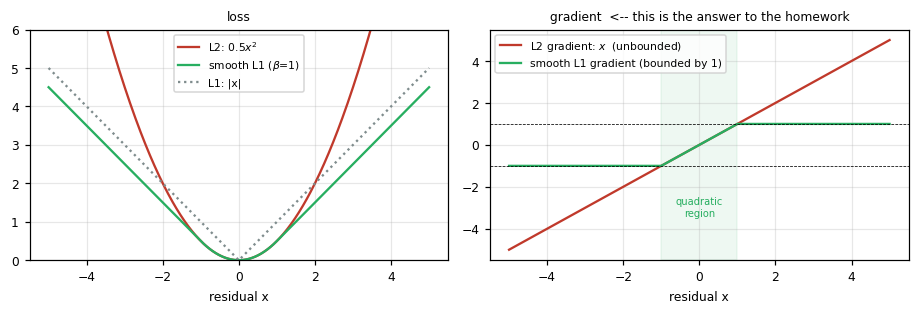

In [18]:
x = torch.linspace(-5, 5, 501)
fig, axes = plt.subplots(1, 2, figsize=(8.4, 2.9))
axes[0].plot(x, 0.5 * x ** 2, label=r'L2: $0.5x^2$', color='#c0392b')
axes[0].plot(x, smooth_l1_scratch(x), label=r'smooth L1 ($\beta$=1)', color='#27ae60')
axes[0].plot(x, x.abs(), label='L1: |x|', color='#7f8c8d', ls=':')
axes[0].set_title('loss', fontsize=8); axes[0].set_xlabel('residual x'); axes[0].set_ylim(0, 6)
axes[0].legend(fontsize=7); axes[0].grid(alpha=0.3)

axes[1].plot(x, x, label=r'L2 gradient: $x$  (unbounded)', color='#c0392b')
axes[1].plot(x, smooth_l1_grad(x), label='smooth L1 gradient (bounded by 1)', color='#27ae60')
axes[1].axhline(1, color='k', lw=0.5, ls='--'); axes[1].axhline(-1, color='k', lw=0.5, ls='--')
axes[1].axvspan(-1, 1, color='#27ae60', alpha=0.08)
axes[1].text(0, -3.4, 'quadratic\nregion', ha='center', fontsize=6.5, color='#27ae60')
axes[1].set_title('gradient  <-- this is the answer to the homework', fontsize=8)
axes[1].set_xlabel('residual x'); axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Interactive: how much of the update does a single outlier own?**

Set up a minibatch of 15 well-fit RoIs (residual about 0.2) plus **one** outlier of size `outlier`. The right
panel shows the fraction of the total gradient magnitude contributed by that single outlier:

$$\text{share} = \frac{|g(\text{outlier})|}{|g(\text{outlier})| + \sum_{\text{inliers}} |g|}$$

Push `outlier` to 20 and watch L2 hand **most of the update** to one bad box, while smooth L1 keeps it capped.
That is "less sensitive to outliers", quantified. Also try `beta`: smaller beta saturates sooner (more robust,
less precise near 0); larger beta behaves more like L2.

In [19]:
def smooth_l1_demo(beta=1.0, outlier=8.0):
    lim = max(3.0, outlier * 1.15)
    x = torch.linspace(-lim, lim, 601)
    inliers = torch.full((15,), 0.2)
    o = torch.tensor([float(outlier)])

    g_in_l2 = inliers.abs().sum()                              # |grad| of L2 for the inliers
    g_out_l2 = o.abs().sum()
    g_in_s = smooth_l1_grad(inliers, beta).abs().sum()
    g_out_s = smooth_l1_grad(o, beta).abs().sum()
    share_l2 = float(g_out_l2 / (g_out_l2 + g_in_l2))
    share_s = float(g_out_s / (g_out_s + g_in_s))

    fig, axes = plt.subplots(1, 3, figsize=(10, 2.7))
    axes[0].plot(x, 0.5 * x ** 2, color='#c0392b', label='L2')
    axes[0].plot(x, smooth_l1_scratch(x, beta), color='#27ae60', label=r'smooth L1 $\beta$=%.2f' % beta)
    axes[0].axvline(outlier, color='k', ls='--', lw=0.8)
    axes[0].set_ylim(0, float(0.5 * lim ** 2) * 0.6); axes[0].set_title('loss', fontsize=8)
    axes[0].legend(fontsize=6.5); axes[0].grid(alpha=0.3); axes[0].set_xlabel('residual')

    axes[1].plot(x, x, color='#c0392b', label='L2 grad')
    axes[1].plot(x, smooth_l1_grad(x, beta), color='#27ae60', label='smooth L1 grad')
    axes[1].axvline(outlier, color='k', ls='--', lw=0.8)
    axes[1].plot([outlier], [outlier], 'o', color='#c0392b', ms=5)
    axes[1].plot([outlier], [float(smooth_l1_grad(o, beta))], 'o', color='#27ae60', ms=5)
    axes[1].set_title('gradient at the outlier: L2 = %.1f, smooth L1 = %.2f'
                      % (outlier, float(smooth_l1_grad(o, beta))), fontsize=7)
    axes[1].legend(fontsize=6.5); axes[1].grid(alpha=0.3); axes[1].set_xlabel('residual')

    b = axes[2].bar(['L2', 'smooth L1'], [share_l2 * 100, share_s * 100], color=['#c0392b', '#27ae60'])
    for r, v in zip(b, [share_l2, share_s]):
        axes[2].text(r.get_x() + r.get_width() / 2, v * 100, ' %.0f%%' % (v * 100), ha='center', va='bottom', fontsize=8)
    axes[2].set_ylim(0, 105); axes[2].set_ylabel('% of total |gradient|')
    axes[2].set_title('share of the update owned by\n1 outlier among 15 good RoIs', fontsize=7.5)
    plt.tight_layout(); plt.show()


widgets.interact(smooth_l1_demo,
                 beta=widgets.FloatSlider(min=0.25, max=3.0, step=0.25, value=1.0, description='beta', continuous_update=False),
                 outlier=widgets.FloatSlider(min=0.5, max=20.0, step=0.5, value=8.0, description='outlier', continuous_update=False));

interactive(children=(FloatSlider(value=1.0, continuous_update=False, description='beta', max=3.0, min=0.25, s…

### 5.5 What exactly does the box regressor predict?

Not raw pixel coordinates. It predicts **scale-invariant offsets relative to the proposal** $P$, so the same
head works for a proposal anywhere in the image at any size:

$$t_x = \frac{G_x - P_x}{P_w}, \quad t_y = \frac{G_y - P_y}{P_h}, \quad t_w = \log\frac{G_w}{P_w}, \quad t_h = \log\frac{G_h}{P_h}$$

- Centre offsets are divided by the proposal's size, so "half a box to the right" means the same thing at
  every scale.
- Sizes are in **log** space, so shrinking and growing are symmetric and the prediction cannot go negative.
- At test time we invert this to get the box back. `decode(encode(P, G)) == G` is an exact identity, so we
  assert it.

We follow Fast R-CNN in **normalising the targets** by their standard deviation (roughly 0.1 for the centres
and 0.2 for the sizes) so that the four components have comparable magnitude and land in smooth L1's
well-behaved region.

In [20]:
def encode_boxes(props, gts):
    '''(P, G) -> regression targets t = (tx, ty, tw, th).'''
    pw = props[:, 2] - props[:, 0]; ph = props[:, 3] - props[:, 1]
    px = props[:, 0] + 0.5 * pw;    py = props[:, 1] + 0.5 * ph
    gw = gts[:, 2] - gts[:, 0];     gh = gts[:, 3] - gts[:, 1]
    gx = gts[:, 0] + 0.5 * gw;      gy = gts[:, 1] + 0.5 * gh
    return torch.stack([(gx - px) / pw, (gy - py) / ph, torch.log(gw / pw), torch.log(gh / ph)], 1)


def decode_boxes(props, deltas):
    '''(P, t) -> predicted box in x1,y1,x2,y2.'''
    pw = props[:, 2] - props[:, 0]; ph = props[:, 3] - props[:, 1]
    px = props[:, 0] + 0.5 * pw;    py = props[:, 1] + 0.5 * ph
    gx = deltas[:, 0] * pw + px;    gy = deltas[:, 1] * ph + py
    gw = torch.exp(deltas[:, 2].clamp(max=4.0)) * pw          # clamp keeps exp from exploding early in training
    gh = torch.exp(deltas[:, 3].clamp(max=4.0)) * ph
    return torch.stack([gx - 0.5 * gw, gy - 0.5 * gh, gx + 0.5 * gw, gy + 0.5 * gh], 1)


BOX_STD = torch.tensor([0.1, 0.1, 0.2, 0.2])                  # Fast R-CNN target normalisation

_p = random_boxes(200, np.random.default_rng(7))
_gq = random_boxes(200, np.random.default_rng(8))
assert torch.allclose(decode_boxes(_p, encode_boxes(_p, _gq)), _gq, atol=1e-4)
print('decode(encode(P, G)) == G for 200 random pairs (max abs err %.2e). OK'
      % (decode_boxes(_p, encode_boxes(_p, _gq)) - _gq).abs().max())

decode(encode(P, G)) == G for 200 random pairs (max abs err 3.81e-06). OK


### 5.6 Turning proposals into training examples

Fast R-CNN's sampling recipe, which we follow:

- A proposal with **IoU >= 0.5** with some ground-truth box is **foreground**; its label $u$ is that object's
  class and its target $v$ is the encoded offset to that box.
- Otherwise it is **background** ($u = 0$), and it gets classification loss only.
- Each minibatch is about **25% foreground**. Left alone, proposals are overwhelmingly background and the
  classifier would learn to always say "background".

Where do the proposals come from? In the real Fast R-CNN, from Selective Search. Running our Python
Selective Search on every image every epoch would be slow, which is *itself the lecture's point* about
region proposals. So we use a fast stand-in with the same statistics: **jittered ground-truth boxes**
(spanning a range of IoU, which naturally supplies hard negatives just below 0.5) plus **random boxes**.

proposals per image 64 | foreground fraction 0.25
class counts (0 = background): [4608, 509, 577, 450]


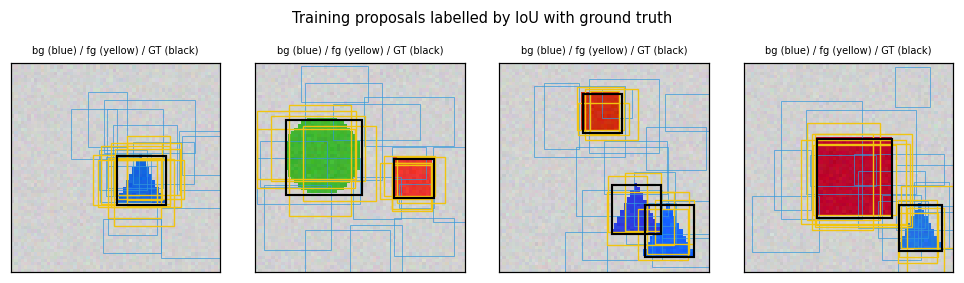

In [21]:
def jitter_boxes(gt, n, rng, smin=0.6, smax=1.5, tmax=0.45):
    '''Random shifts/rescales of one GT box -> proposals spanning a range of IoU.'''
    w = gt[2] - gt[0]; h = gt[3] - gt[1]
    cx = gt[0] + 0.5 * w; cy = gt[1] + 0.5 * h
    dx = torch.tensor(rng.uniform(-tmax, tmax, n), dtype=torch.float32) * w
    dy = torch.tensor(rng.uniform(-tmax, tmax, n), dtype=torch.float32) * h
    nw = w * torch.tensor(rng.uniform(smin, smax, n), dtype=torch.float32)
    nh = h * torch.tensor(rng.uniform(smin, smax, n), dtype=torch.float32)
    ncx, ncy = cx + dx, cy + dy
    return torch.stack([ncx - nw / 2, ncy - nh / 2, ncx + nw / 2, ncy + nh / 2], 1).clamp(0, IMG)


def build_proposal_set(gt_boxes, gt_labels, rng, n_fg=16, n_bg=48):
    '''Returns (proposals, labels u, targets v) with roughly 25% foreground.'''
    cands = [random_boxes(150, rng)] + [jitter_boxes(gt_boxes[i], 80, rng) for i in range(len(gt_boxes))]
    cands = torch.cat(cands, 0)
    cands = cands[(cands[:, 2] - cands[:, 0] >= 4) & (cands[:, 3] - cands[:, 1] >= 4)]
    best_iou, best_g = box_iou_scratch(cands, gt_boxes).max(1)
    fg = torch.where(best_iou >= 0.5)[0]
    bg = torch.where(best_iou < 0.5)[0]

    def take(idx, n):
        if len(idx) == 0:
            return idx
        return idx[torch.tensor(rng.choice(len(idx), size=n, replace=len(idx) < n), dtype=torch.long)]

    fg, bg = take(fg, n_fg), take(bg, n_bg)
    sel = torch.cat([fg, bg])
    props = cands[sel]
    labels = torch.zeros(len(sel), dtype=torch.long)
    labels[:len(fg)] = gt_labels[best_g[fg]]
    targets = torch.zeros(len(sel), 4)
    if len(fg):
        targets[:len(fg)] = encode_boxes(cands[fg], gt_boxes[best_g[fg]]) / BOX_STD
    return props, labels, targets


_rng = np.random.default_rng(5)
P_tr, L_tr, T_tr = [], [], []
for i in range(N_TRAIN):
    p, l, t = build_proposal_set(tr_boxes[i], tr_labels[i], _rng)
    P_tr.append(p); L_tr.append(l); T_tr.append(t)
P_tr, L_tr, T_tr = torch.stack(P_tr), torch.stack(L_tr), torch.stack(T_tr)
P_tr, L_tr, T_tr = P_tr.to(device), L_tr.to(device), T_tr.to(device)
print('proposals per image', P_tr.shape[1], '| foreground fraction %.2f' % (L_tr >= 1).float().mean().item())
print('class counts (0 = background):', torch.bincount(L_tr.reshape(-1)).tolist())

fig, axes = plt.subplots(1, 4, figsize=(9, 2.4))
for k, ax in enumerate(axes):
    show_img(ax, tr_imgs[k])
    draw_boxes(ax, P_tr[k][L_tr[k] == 0][:14].cpu(), color='#3498db', lw=0.6, alpha=0.75)
    draw_boxes(ax, P_tr[k][L_tr[k] >= 1][:10].cpu(), color='#f1c40f', lw=0.9)
    draw_boxes(ax, tr_boxes[k], color='k', lw=1.4)
    ax.set_title('bg (blue) / fg (yellow) / GT (black)', fontsize=6.5)
fig.suptitle('Training proposals labelled by IoU with ground truth', y=1.04)
plt.tight_layout(); plt.show()

### 5.7 The head, the loss, and end-to-end training

- **Head:** RoI-pooled `(32, 4, 4)` feature -> flatten -> FC(512 -> 64) -> ReLU -> two siblings:
  - a **softmax classifier** over 4 classes (background + 3),
  - a **box regressor** emitting `4 x NUM_CLASSES` offsets (class-specific $t^u$).
- **Loss:** exactly the formula in 5.4, averaged over the RoIs of the minibatch. We write the Iverson
  bracket literally as a mask `u >= 1`, and normalise $L_{loc}$ by the **total** RoI count so that the
  per-RoI expression matches the slide.
- **One optimiser, one backward pass, backbone included.** This is the "no SVMs, no multi-stage pipeline"
  claim made concrete.

training Fast R-CNN (backbone + head, one multi-task loss, lambda = 1)...
  step    0 | loss 2.0041 | L_cls 1.4017 | L_loc 0.6024 | RoI acc 0.109


/var/folders/j0/z7mrqrv9121_0pm8njw3pbxh0000gp/T/ipykernel_41926/2505659916.py:48: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  % (s, float(loss), float(lc), float(ll), acc))


  step  100 | loss 0.6336 | L_cls 0.2696 | L_loc 0.3640 | RoI acc 0.887


  step  200 | loss 0.3864 | L_cls 0.1876 | L_loc 0.1989 | RoI acc 0.908


  step  300 | loss 0.3530 | L_cls 0.1943 | L_loc 0.1587 | RoI acc 0.908


  step  400 | loss 0.2755 | L_cls 0.1399 | L_loc 0.1356 | RoI acc 0.939


  step  500 | loss 0.2801 | L_cls 0.1384 | L_loc 0.1417 | RoI acc 0.953


  step  599 | loss 0.2660 | L_cls 0.1420 | L_loc 0.1240 | RoI acc 0.938
done in 2.3 s


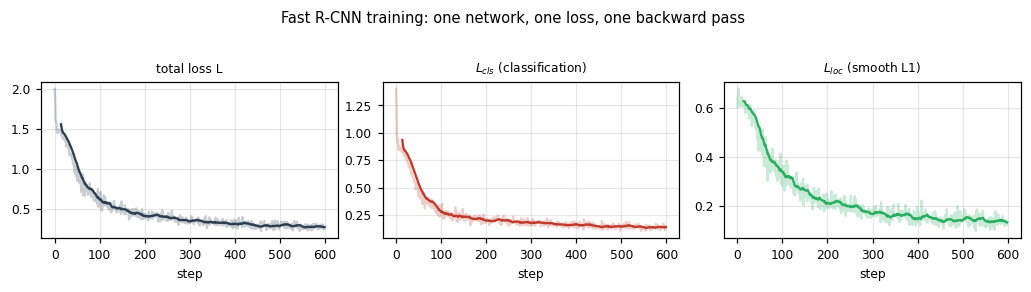

In [22]:
class DetHead(nn.Module):
    '''Fast R-CNN head: shared FC trunk + sibling classifier and class-specific box regressor.'''
    def __init__(self, in_ch=32, pool=POOL, hidden=64, nc=NUM_CLASSES):
        super().__init__()
        self.nc = nc
        self.trunk = nn.Sequential(nn.Linear(in_ch * pool * pool, hidden), nn.ReLU(inplace=True))
        self.cls = nn.Linear(hidden, nc)          # -> p
        self.bbox = nn.Linear(hidden, nc * 4)     # -> t^k for every class k

    def forward(self, x):
        z = self.trunk(x.flatten(1))
        return self.cls(z), self.bbox(z).view(-1, self.nc, 4)


def multitask_loss(logits, deltas, u, v, lam=1.0):
    '''L(p,u,t^u,v) = L_cls(p,u) + lam * [u>=1] * L_loc(t^u, v), averaged over RoIs.'''
    L_cls = F.cross_entropy(logits, u)                       # -log p_u
    fg = u >= 1                                              # the Iverson bracket [u >= 1]
    n = u.numel()
    if fg.any():
        t_u = deltas[fg][torch.arange(int(fg.sum()), device=deltas.device), u[fg]]   # pick the true class row
        L_loc = smooth_l1_scratch(t_u - v[fg]).sum() / n
    else:
        L_loc = logits.sum() * 0.0
    return L_cls + lam * L_loc, L_cls.detach(), L_loc.detach()


def train_fast_rcnn(lam=1.0, steps=600, bs=8, seed=0, log_every=100):
    torch.manual_seed(seed)
    bb = Backbone().to(device)
    head = DetHead().to(device)
    opt = torch.optim.Adam(list(bb.parameters()) + list(head.parameters()), lr=3e-3)
    g = np.random.default_rng(seed)
    hist = []
    for s in range(steps):
        idx = g.choice(N_TRAIN, bs, replace=False)
        fm = bb(tr_imgs[idx].to(device))                     # ONE CNN pass for the whole batch of images
        rois = torch.cat([torch.cat([torch.full((P_tr[i].shape[0], 1), float(b), device=device), P_tr[i]], 1)
                          for b, i in enumerate(idx)], 0)
        pooled = torchvision.ops.roi_pool(fm, rois, (POOL, POOL), 1.0 / bb.stride)
        logits, deltas = head(pooled)
        loss, lc, ll = multitask_loss(logits, deltas, L_tr[idx].reshape(-1), T_tr[idx].reshape(-1, 4), lam)
        opt.zero_grad(); loss.backward(); opt.step()
        hist.append((float(loss.detach()), float(lc), float(ll)))
        if log_every and (s % log_every == 0 or s == steps - 1):
            acc = (logits.argmax(1) == L_tr[idx].reshape(-1)).float().mean().item()
            print('  step %4d | loss %.4f | L_cls %.4f | L_loc %.4f | RoI acc %.3f'
                  % (s, float(loss), float(lc), float(ll), acc))
    return bb, head, np.array(hist)


print('training Fast R-CNN (backbone + head, one multi-task loss, lambda = 1)...')
t0 = time.perf_counter()
bb, head, hist = train_fast_rcnn(lam=1.0, steps=600)
print('done in %.1f s' % (time.perf_counter() - t0))

fig, axes = plt.subplots(1, 3, figsize=(9.5, 2.5))
k = 15
sm = lambda a: np.convolve(a, np.ones(k) / k, mode='valid')
for ax, col, name, c in zip(axes, [0, 1, 2], ['total loss L', r'$L_{cls}$ (classification)', r'$L_{loc}$ (smooth L1)'],
                            ['#2c3e50', '#c0392b', '#27ae60']):
    ax.plot(hist[:, col], alpha=0.25, color=c)
    ax.plot(np.arange(k - 1, len(hist)), sm(hist[:, col]), color=c)
    ax.set_title(name, fontsize=8); ax.set_xlabel('step'); ax.grid(alpha=0.3)
fig.suptitle('Fast R-CNN training: one network, one loss, one backward pass', y=1.03)
plt.tight_layout(); plt.show()

### 5.8 From proposals to detections: NMS

The head scores every proposal, so a single object collects many overlapping high-scoring boxes.
**Non-Maximum Suppression** keeps the best and removes its duplicates:

- Sort boxes by score, descending.
- Take the top box, keep it, and delete every remaining box whose IoU with it exceeds a threshold.
- Repeat with what survives.

NMS is part of the **detector**, not of the metric: the lecture's evaluation recipe begins "run the object
detector on all test images (**with NMS**)". We implement it from scratch and check it against
`torchvision.ops.nms` (using distinct scores, since ties are broken arbitrarily).

In [23]:
def nms_scratch(boxes, scores, iou_thr):
    '''Greedy NMS. Returns kept indices, ordered by decreasing score.'''
    order = torch.argsort(scores, descending=True)
    keep = []
    while order.numel() > 0:
        i = int(order[0])
        keep.append(i)                                   # highest scoring survivor
        if order.numel() == 1:
            break
        rest = order[1:]
        ious = box_iou_scratch(boxes[i:i + 1], boxes[rest])[0]
        order = rest[ious <= iou_thr]                    # drop anything that overlaps it too much
    return torch.tensor(keep, dtype=torch.long, device=boxes.device)


_g = np.random.default_rng(4)
_bx = random_boxes(80, _g)
_sc = torch.tensor(_g.permutation(80) / 80.0, dtype=torch.float32)     # distinct scores -> no ties
for _t in [0.1, 0.3, 0.5, 0.7, 0.9]:
    assert torch.equal(nms_scratch(_bx, _sc, _t), torchvision.ops.nms(_bx, _sc, _t)), _t
print('nms_scratch matches torchvision.ops.nms exactly for thresholds 0.1 to 0.9. OK')


@torch.no_grad()
def detect(bb, head, imgs, props_list, score_thr=0.05, nms_thr=0.3):
    '''Full Fast R-CNN inference. Returns per image a (D,6) tensor: x1,y1,x2,y2,score,class.'''
    out = []
    for i in range(imgs.shape[0]):
        pr = props_list[i].to(device)
        fm = bb(imgs[i:i + 1].to(device))                               # one CNN pass
        rois = torch.cat([torch.zeros(pr.shape[0], 1, device=device), pr], 1)
        logits, deltas = head(torchvision.ops.roi_pool(fm, rois, (POOL, POOL), 1.0 / bb.stride))
        deltas = deltas * BOX_STD.to(device)                            # undo target normalisation
        probs = logits.softmax(1)
        per = []
        for c in range(1, NUM_CLASSES):                                 # NMS is applied per class
            sc = probs[:, c]
            bx = decode_boxes(pr, deltas[:, c]).clamp(0, IMG)
            m = sc > score_thr
            if m.sum() == 0:
                continue
            bx, sc = bx[m], sc[m]
            k = nms_scratch(bx, sc, nms_thr)
            per.append(torch.cat([bx[k], sc[k][:, None], torch.full((len(k), 1), float(c), device=device)], 1))
        out.append(torch.cat(per, 0).cpu() if per else torch.zeros(0, 6))
    return out


def sslike_proposals(gt_boxes, rng, n_rand=60):
    '''Stand-in for Selective Search output at test time: good coverage + lots of background.'''
    c = torch.cat([random_boxes(n_rand, rng)] +
                  [jitter_boxes(gt_boxes[i], 12, rng, smin=0.75, smax=1.3, tmax=0.25) for i in range(len(gt_boxes))], 0)
    return c[(c[:, 2] - c[:, 0] >= 4) & (c[:, 3] - c[:, 1] >= 4)]


_rng = np.random.default_rng(99)
te_props = [sslike_proposals(te_boxes[i], _rng) for i in range(N_TEST)]
dets_ss = detect(bb, head, te_imgs, te_props)
print('test proposals per image: %.1f | detections kept after NMS: %.1f'
      % (np.mean([len(p) for p in te_props]), np.mean([len(d) for d in dets_ss])))

nms_scratch matches torchvision.ops.nms exactly for thresholds 0.1 to 0.9. OK
test proposals per image: 84.8 | detections kept after NMS: 2.3


Predictions vs ground truth. Note the boxes are **not** the proposals: the regressor has moved them.

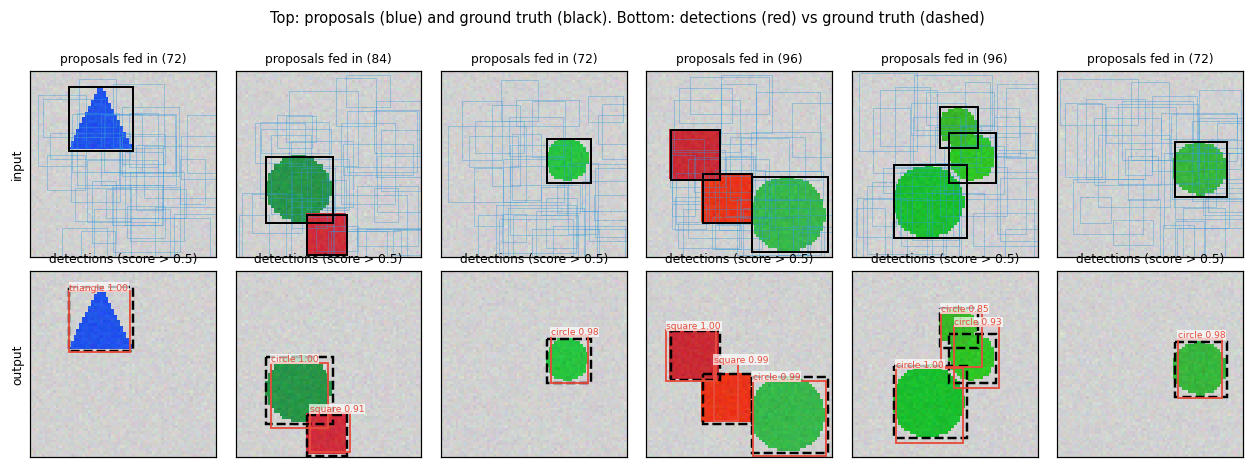

In [24]:
fig, axes = plt.subplots(2, 6, figsize=(11.5, 4.1))
for k in range(6):
    show_img(axes[0, k], te_imgs[k], 'proposals fed in (%d)' % len(te_props[k]))
    draw_boxes(axes[0, k], te_props[k][:35], color='#3498db', lw=0.4, alpha=0.6)
    draw_boxes(axes[0, k], te_boxes[k], color='k', lw=1.3)

    d = dets_ss[k]
    d = d[d[:, 4] > 0.5]
    show_img(axes[1, k], te_imgs[k], 'detections (score > 0.5)')
    draw_boxes(axes[1, k], te_boxes[k], color='k', lw=1.6, ls='--')
    draw_boxes(axes[1, k], d[:, :4], color='#e74c3c', lw=1.2,
               texts=['%s %.2f' % (CLASS_NAMES[int(c)], s) for s, c in zip(d[:, 4], d[:, 5])])
axes[0, 0].set_ylabel('input'); axes[1, 0].set_ylabel('output')
fig.suptitle('Top: proposals (blue) and ground truth (black). Bottom: detections (red) vs ground truth (dashed)', y=1.02)
plt.tight_layout(); plt.show()

## 6. R-CNN vs Fast R-CNN: where did the time go?

The lecture's numbers (from cs231n), for VGG-16 on PASCAL VOC:

| | Training time | Test time **including** proposals | Test time **excluding** proposals |
|---|---|---|---|
| R-CNN | 84 h | 49 s | 47 s |
| SPP-Net | 25.5 h | 4.3 s | 2.3 s |
| **Fast R-CNN** | **8.75 h** | **2.3 s** | **0.32 s** |

Read the last row carefully:

- Fast R-CNN's **network** takes 0.32 s per image. It is fast.
- Fast R-CNN's **total** is 2.3 s per image. So about **2 s, roughly 86% of test time, is Selective Search**.
- We sped up the CNN by 146x (47 s -> 0.32 s) and the end-to-end detector only got 21x faster. Amdahl's law:
  once you fix the bottleneck, the next bottleneck is in charge.

> **Region proposals are now slowing down Fast R-CNN.**

The proposals are computed on the CPU by a hand-designed algorithm that knows nothing about the task,
while a GPU sits idle next to it. That is the setup for Faster R-CNN.

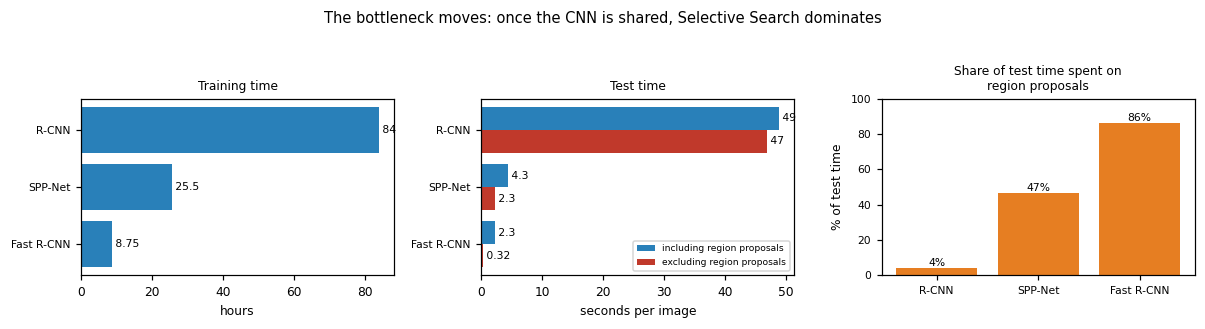

In [25]:
labels_ = ['R-CNN', 'SPP-Net', 'Fast R-CNN']
train_h = [84, 25.5, 8.75]
test_incl = [49, 4.3, 2.3]
test_excl = [47, 2.3, 0.32]

fig, axes = plt.subplots(1, 3, figsize=(11, 2.8))
y = np.arange(3)
axes[0].barh(y, train_h, color='#2980b9')
axes[0].set_yticks(y); axes[0].set_yticklabels(labels_, fontsize=7); axes[0].invert_yaxis()
axes[0].set_xlabel('hours'); axes[0].set_title('Training time', fontsize=8)
for i, v in enumerate(train_h):
    axes[0].text(v, i, ' %g' % v, va='center', fontsize=7)

axes[1].barh(y - 0.2, test_incl, 0.4, color='#2980b9', label='including region proposals')
axes[1].barh(y + 0.2, test_excl, 0.4, color='#c0392b', label='excluding region proposals')
axes[1].set_yticks(y); axes[1].set_yticklabels(labels_, fontsize=7); axes[1].invert_yaxis()
axes[1].set_xlabel('seconds per image'); axes[1].set_title('Test time', fontsize=8); axes[1].legend(fontsize=6)
for i, (a, b_) in enumerate(zip(test_incl, test_excl)):
    axes[1].text(a, i - 0.2, ' %g' % a, va='center', fontsize=7)
    axes[1].text(b_, i + 0.2, ' %g' % b_, va='center', fontsize=7)

frac = [(a - b_) / a * 100 for a, b_ in zip(test_incl, test_excl)]
axes[2].bar(labels_, frac, color='#e67e22')
axes[2].set_ylabel('% of test time'); axes[2].set_ylim(0, 100)
axes[2].set_title('Share of test time spent on\nregion proposals', fontsize=8)
for i, v in enumerate(frac):
    axes[2].text(i, v, '%.0f%%' % v, ha='center', va='bottom', fontsize=7)
axes[2].tick_params(labelsize=7)
fig.suptitle('The bottleneck moves: once the CNN is shared, Selective Search dominates', y=1.04)
plt.tight_layout(); plt.show()

## 7. Faster R-CNN (Ren et al, NeurIPS 2015)

The idea in one sentence:

> **Replace Selective Search with a Region Proposal Network (RPN)**, a small conv net that proposes regions
> from the feature map **we have already computed**.

Why this is nearly free:

- The RPN runs on the **same shared feature map** the detector already needs. The expensive convolutions are
  paid for once and now serve both jobs.
- The RPN is a couple of conv layers, so proposals cost **~10 ms** instead of ~2 s.
- The proposals are **learned**, so they are tuned to the actual task instead of being generic colour blobs.

### 7.1 Anchor boxes

A conv layer at one feature location can only emit a fixed number of outputs, but a location may contain
objects of different size and shape. So Faster R-CNN attaches $K$ **anchor boxes** to every location:
a fixed set of reference boxes at several **scales** and **aspect ratios**.

- The RPN never predicts a box from nothing. It predicts, **for each anchor**:
  - **objectness**: is there an object here? -> $K \times H_f \times W_f$ outputs
  - **box transforms**: the same $(t_x, t_y, t_w, t_h)$ offsets from 5.5, but relative to the anchor
    -> $4K \times H_f \times W_f$ outputs
- Anchors turn "where are the objects?" (an unbounded search) into "which of these ~2000 fixed boxes contain
  an object, and how should each be nudged?" (a dense classification + regression problem).
- The lecture's figure: a `3 x 640 x 480` image -> `512 x 20 x 15` features -> `K x 20 x 15` objectness and
  `4K x 20 x 15` box transforms.

Our setup: a 16 x 16 feature map, 3 scales x 3 ratios = **9 anchors per location** = 2304 anchors per image.

In [26]:
FS = IMG // STRIDE                       # feature map side: 16
SCALES = [10., 16., 24.]                 # anchor "areas" as side lengths, in image pixels
RATIOS = [0.5, 1.0, 2.0]                 # h / w


def make_anchors(fs, stride, scales, ratios):
    '''Returns (A*fs*fs, 4) anchors ordered (anchor_type, row, col) to match a conv output, and A.'''
    sizes = [(s * (1.0 / r) ** 0.5, s * r ** 0.5) for s in scales for r in ratios]   # (w, h), area = s^2
    A = len(sizes)
    centres = (torch.arange(fs, dtype=torch.float32) + 0.5) * stride                 # cell centres in image px
    gy, gx = torch.meshgrid(centres, centres, indexing='ij')
    out = torch.zeros(A, fs, fs, 4)
    for k, (w, h) in enumerate(sizes):
        out[k, :, :, 0] = gx - w / 2; out[k, :, :, 1] = gy - h / 2
        out[k, :, :, 2] = gx + w / 2; out[k, :, :, 3] = gy + h / 2
    return out.reshape(-1, 4), A


anchors, A = make_anchors(FS, STRIDE, SCALES, RATIOS)
anchors = anchors.to(device)
print('feature map %dx%d | %d anchors per location | %d anchors per image' % (FS, FS, A, anchors.shape[0]))
inside = ((anchors[:, 0] >= 0) & (anchors[:, 1] >= 0) & (anchors[:, 2] <= IMG) & (anchors[:, 3] <= IMG))
print('anchors fully inside the image: %.0f%% (the paper ignores cross-boundary anchors when training)'
      % (100 * inside.float().mean()))

# how well can anchors possibly cover our objects? an upper bound on RPN recall
_all_gt = torch.cat([b for b in tr_boxes if len(b)], 0).to(device)
_best = box_iou_scratch(anchors, _all_gt).max(0).values
print('best anchor IoU per GT object: mean %.2f, min %.2f -> %.0f%% of objects have an anchor with IoU >= 0.5'
      % (_best.mean(), _best.min(), 100 * (_best >= 0.5).float().mean()))

feature map 16x16 | 9 anchors per location | 2304 anchors per image
anchors fully inside the image: 54% (the paper ignores cross-boundary anchors when training)
best anchor IoU per GT object: mean 0.76, min 0.58 -> 100% of objects have an anchor with IoU >= 0.5


Left: the 9 anchors of a single location. Middle: anchors tiled over every 3rd location. Right: the anchors
that our target-assignment rule will call "positive" for this image.

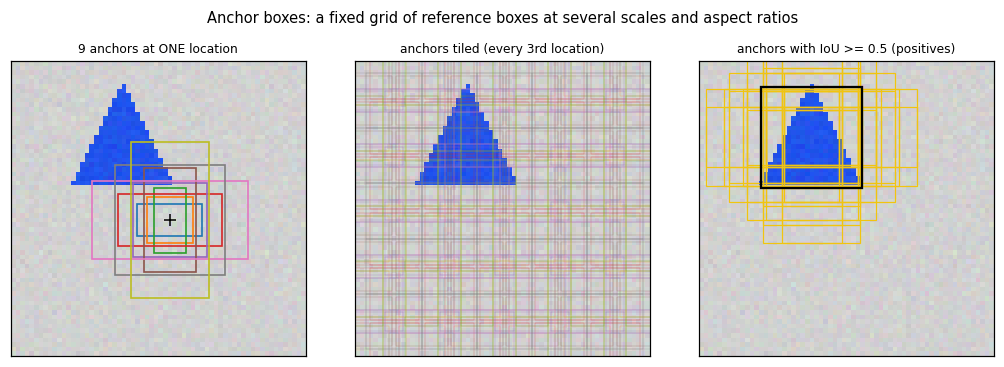

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(9.5, 3.2))
_am = anchors.reshape(A, FS, FS, 4).cpu()

show_img(axes[0], te_imgs[0], '%d anchors at ONE location' % A)
cmap = plt.get_cmap('tab10')
for k in range(A):
    draw_boxes(axes[0], _am[k, FS // 2, FS // 2][None], color=cmap(k % 10), lw=1.1)
axes[0].plot([(FS // 2 + 0.5) * STRIDE], [(FS // 2 + 0.5) * STRIDE], 'k+', ms=8)

show_img(axes[1], te_imgs[0], 'anchors tiled (every 3rd location)')
for k in range(A):
    draw_boxes(axes[1], _am[k, ::3, ::3].reshape(-1, 4), color=cmap(k % 10), lw=0.3, alpha=0.5)

g0 = te_boxes[0].to(device)
_iou0 = box_iou_scratch(anchors, g0).max(1).values
show_img(axes[2], te_imgs[0], 'anchors with IoU >= 0.5 (positives)')
draw_boxes(axes[2], anchors[_iou0 >= 0.5].cpu(), color='#f1c40f', lw=0.8)
draw_boxes(axes[2], te_boxes[0], color='k', lw=1.5)
fig.suptitle('Anchor boxes: a fixed grid of reference boxes at several scales and aspect ratios', y=1.02)
plt.tight_layout(); plt.show()

**Interactive:** change the scales, aspect ratios and stride, and watch the anchor count and layout change.

- **Stride** controls how many *locations* exist: halving the stride quadruples the anchors (and the cost).
- **Scales / ratios** control how many anchors sit at *each* location: this is $K$.
- Total anchors $= K \times H_f \times W_f$. The panel reports the resulting **best-case recall**: the fraction
  of real objects in this image that have *some* anchor with IoU >= 0.5. If your anchors cannot cover the
  objects, no amount of training will fix the RPN. That is the design question anchors pose.

In [28]:
_gt_demo = torch.cat([b for b in te_boxes if len(b)], 0)


def anchor_demo(stride=4, base=16, n_scales=3, n_ratios=3):
    scales = [base * m for m in [1.0, 0.6, 1.5][:n_scales]]
    ratios = [1.0, 0.5, 2.0][:n_ratios]
    fs = IMG // stride
    anc, K = make_anchors(fs, stride, scales, ratios)
    iou = box_iou_scratch(anc, _gt_demo).max(0).values
    rec = float((iou >= 0.5).float().mean())

    fig, axes = plt.subplots(1, 3, figsize=(9.5, 3.0))
    am = anc.reshape(K, fs, fs, 4)
    show_img(axes[0], te_imgs[0], '%d anchors at one location' % K)
    for k in range(K):
        draw_boxes(axes[0], am[k, fs // 2, fs // 2][None], color=cmap(k % 10), lw=1.2)
    step = max(1, fs // 6)
    show_img(axes[1], te_imgs[0], 'tiled (every %d locations)' % step)
    for k in range(K):
        draw_boxes(axes[1], am[k, ::step, ::step].reshape(-1, 4), color=cmap(k % 10), lw=0.3, alpha=0.5)
    show_img(axes[2], te_imgs[0], 'positives for this image')
    i0 = box_iou_scratch(anc, te_boxes[0]).max(1).values
    draw_boxes(axes[2], anc[i0 >= 0.5], color='#f1c40f', lw=0.8)
    draw_boxes(axes[2], te_boxes[0], color='k', lw=1.5)
    fig.suptitle('stride %d -> %dx%d = %d locations | K = %d anchors/location | TOTAL %d anchors'
                 '\nbest-case recall over the whole test set (some anchor with IoU >= 0.5): %.0f%%'
                 % (stride, fs, fs, fs * fs, K, K * fs * fs, 100 * rec), y=1.09, fontsize=8)
    plt.tight_layout(); plt.show()


widgets.interact(anchor_demo,
                 stride=widgets.SelectionSlider(options=[2, 4, 8, 16], value=4, description='stride', continuous_update=False),
                 base=widgets.IntSlider(min=6, max=32, step=2, value=16, description='base scale', continuous_update=False),
                 n_scales=widgets.IntSlider(min=1, max=3, step=1, value=3, description='# scales', continuous_update=False),
                 n_ratios=widgets.IntSlider(min=1, max=3, step=1, value=3, description='# ratios', continuous_update=False));

interactive(children=(SelectionSlider(continuous_update=False, description='stride', index=1, options=(2, 4, 8…

### 7.2 The Region Proposal Network

Structure (matching the lecture's block diagram):

- A **fully convolutional layer** slides over the shared feature map (3x3 conv).
- Two 1x1 conv siblings: **objectness classification** ($K$ outputs per location) and
  **bounding-box regression** ($4K$ outputs per location).

Training targets, per anchor:

- IoU **>= 0.5** with some ground-truth box -> **positive** (the paper uses 0.7; our objects are small so we
  relax it), and additionally the **best anchor for each ground-truth box is always positive**, which
  guarantees no object is left without a positive anchor.
- IoU **< 0.3** -> **negative**. In between -> **ignored** (label -1), because such anchors are ambiguous and
  would only inject noise.
- We sample about 32 positives and 32 negatives per image: anchors are ~99% background otherwise.

Note the loss below is **the same multi-task structure** as Fast R-CNN's: a classification term plus a smooth
L1 box term applied to positives only. Same idea, one level down: 2-way objectness rather than 4-way class.

**This is step 3 of the 4-step schedule:** we train the RPN on top of the **frozen** backbone that the
detector already trained. The features are shared, and the RPN just learns to read them.

In [29]:
class RPN(nn.Module):
    def __init__(self, in_ch=32, A=9):
        super().__init__()
        self.A = A
        self.conv = nn.Sequential(nn.Conv2d(in_ch, 32, 3, padding=1), nn.ReLU(inplace=True))  # sliding window
        self.obj = nn.Conv2d(32, A, 1)          # "anchor is an object?"  -> K x Hf x Wf
        self.reg = nn.Conv2d(32, 4 * A, 1)      # "box transforms"        -> 4K x Hf x Wf

    def forward(self, f):
        z = self.conv(f)
        n = f.shape[0]
        o = self.obj(z).reshape(n, -1)                                          # (N, A*Hf*Wf)
        d = self.reg(z).reshape(n, self.A, 4, FS, FS).permute(0, 1, 3, 4, 2).reshape(n, -1, 4)
        return o, d                                                             # order matches make_anchors


def rpn_targets(anchors, gt, pos_thr=0.5, neg_thr=0.3):
    '''label: 1 = object, 0 = background, -1 = ignore.'''
    lab = torch.full((anchors.shape[0],), -1.0, device=anchors.device)
    tgt = torch.zeros(anchors.shape[0], 4, device=anchors.device)
    if len(gt) == 0:
        lab[:] = 0.0
        return lab, tgt
    ious = box_iou_scratch(anchors, gt)
    best_iou, best_g = ious.max(1)
    lab[best_iou < neg_thr] = 0.0
    lab[best_iou >= pos_thr] = 1.0
    top_a = ious.argmax(0)                       # best anchor for each GT is forced positive
    lab[top_a] = 1.0
    best_g[top_a] = torch.arange(len(gt), device=anchors.device)
    pos = lab == 1
    tgt[pos] = encode_boxes(anchors[pos], gt[best_g[pos]]) / BOX_STD.to(anchors.device)
    return lab, tgt


RL, RT = [], []
for i in range(N_TRAIN):
    l, t = rpn_targets(anchors, tr_boxes[i].to(device))
    RL.append(l); RT.append(t)
RL, RT = torch.stack(RL), torch.stack(RT)
print('per image: %.0f positive anchors, %.0f negative, %.0f ignored'
      % ((RL == 1).float().sum(1).mean(), (RL == 0).float().sum(1).mean(), (RL == -1).float().sum(1).mean()))

torch.manual_seed(1)
rpn = RPN(A=A).to(device)
for p in bb.parameters():
    p.requires_grad_(False)                      # STEP 3: freeze the shared CNN, train only the RPN
opt = torch.optim.Adam(rpn.parameters(), lr=3e-3)
g = np.random.default_rng(1)

print('\ntraining the RPN on the frozen shared backbone...')
t0 = time.perf_counter()
rpn_hist = []
for s in range(400):
    idx = g.choice(N_TRAIN, 8, replace=False)
    with torch.no_grad():
        fm = bb(tr_imgs[idx].to(device))         # shared features, no gradient flows into the backbone
    o, d = rpn(fm)
    loss_o = 0.0; loss_r = 0.0
    for b in range(len(idx)):
        p_idx = torch.where(RL[idx[b]] == 1)[0]
        n_idx = torch.where(RL[idx[b]] == 0)[0]
        npos = min(len(p_idx), 32)
        p_sel = p_idx[torch.randperm(len(p_idx), device=device)[:npos]]
        n_sel = n_idx[torch.randperm(len(n_idx), device=device)[:64 - npos]]
        sel = torch.cat([p_sel, n_sel])
        y = torch.cat([torch.ones(len(p_sel), device=device), torch.zeros(len(n_sel), device=device)])
        loss_o = loss_o + F.binary_cross_entropy_with_logits(o[b][sel], y)          # objectness
        if len(p_sel):                                                             # smooth L1 on positives only
            loss_r = loss_r + smooth_l1_scratch(d[b][p_sel] - RT[idx[b]][p_sel]).sum() / len(sel)
    loss = (loss_o + loss_r) / len(idx)
    opt.zero_grad(); loss.backward(); opt.step()
    rpn_hist.append(float(loss.detach()))
    if s % 100 == 0 or s == 399:
        print('  step %4d | RPN loss %.4f' % (s, float(loss)))
print('RPN trained in %.1f s' % (time.perf_counter() - t0))

per image: 34 positive anchors, 2119 negative, 151 ignored

training the RPN on the frozen shared backbone...
  step    0 | RPN loss 2.1504


  step  100 | RPN loss 0.1343


  step  200 | RPN loss 0.1717


  step  300 | RPN loss 0.1352


  step  399 | RPN loss 0.1239
RPN trained in 1.5 s


**What did the RPN learn?** The objectness heatmap below is $\max_K \sigma(\text{objectness})$ at each of the
16 x 16 feature locations. It should light up on the shapes and stay dark on the background, having never
been told what a "square" or a "circle" is: only whether an anchor overlaps *something*.

Turning objectness into proposals: take the top-scoring anchors, apply their predicted box transforms,
run NMS, keep the survivors.

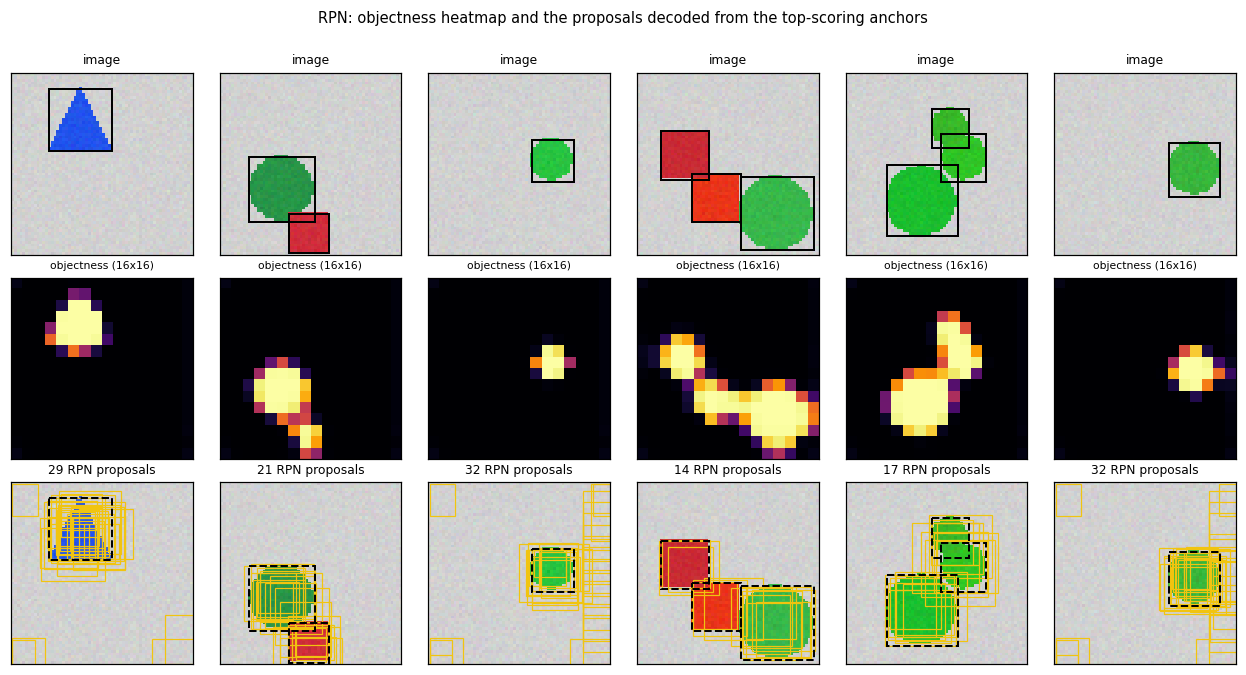

In [30]:
@torch.no_grad()
def rpn_propose(img, topk_pre=150, nms_thr=0.7, topk_post=32):
    '''Shared backbone -> RPN -> decode anchors -> NMS -> proposals.'''
    fm = bb(img.to(device))
    o, d = rpn(fm)
    sc = o[0].sigmoid()
    v, i = sc.topk(min(topk_pre, sc.numel()))
    bx = decode_boxes(anchors[i], d[0][i] * BOX_STD.to(device)).clamp(0, IMG)
    ok = (bx[:, 2] - bx[:, 0] > 2) & (bx[:, 3] - bx[:, 1] > 2)
    bx, v = bx[ok], v[ok]
    keep = nms_scratch(bx, v, nms_thr)[:topk_post]
    return bx[keep].cpu(), v[keep].cpu(), sc.reshape(A, FS, FS).max(0).values.cpu()


fig, axes = plt.subplots(3, 6, figsize=(11.5, 6))
for k in range(6):
    p, v, heat = rpn_propose(te_imgs[k:k + 1])
    show_img(axes[0, k], te_imgs[k], 'image')
    draw_boxes(axes[0, k], te_boxes[k], color='k', lw=1.3)
    axes[1, k].imshow(heat.numpy(), cmap='inferno', interpolation='nearest', vmin=0, vmax=1)
    axes[1, k].set_xticks([]); axes[1, k].set_yticks([])
    axes[1, k].set_title('objectness (16x16)', fontsize=7)
    show_img(axes[2, k], te_imgs[k], '%d RPN proposals' % len(p))
    draw_boxes(axes[2, k], p, color='#f1c40f', lw=0.8)
    draw_boxes(axes[2, k], te_boxes[k], color='k', lw=1.3, ls='--')
fig.suptitle('RPN: objectness heatmap and the proposals decoded from the top-scoring anchors', y=1.01)
plt.tight_layout(); plt.show()

**The verdict.** We now swap the Selective-Search-style proposals for RPN proposals and feed the **same
already-trained detector head**. If Faster R-CNN's claim is right, we should get at least the same quality
from **far fewer** proposals, at a fraction of the cost.

proposal method                     per image recall@0.5   time/image
Selective-Search-like (stand-in)         84.8       1.00       13.4 ms
RPN (learned)                            22.1       1.00        1.6 ms

The RPN reaches the same recall with roughly 4x fewer proposals,
and fewer proposals also makes the SECOND stage cheaper: the head runs once per proposal.


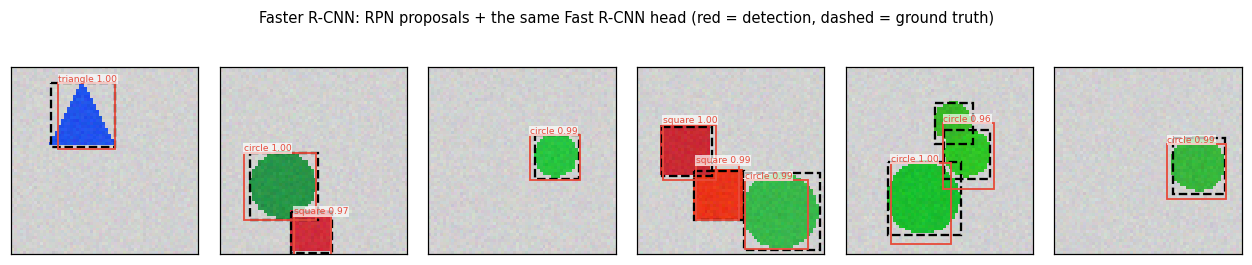

In [31]:
rpn_props = [rpn_propose(te_imgs[i:i + 1])[0] for i in range(N_TEST)]


def recall_at(props_list, thr=0.5):
    hit = tot = 0
    for i in range(N_TEST):
        tot += len(te_boxes[i])
        if len(props_list[i]) == 0:
            continue
        hit += int((box_iou_scratch(props_list[i], te_boxes[i]).max(0).values >= thr).sum())
    return hit / max(tot, 1)


t_ss = bench(lambda: selective_search(ss_img, cell=4), repeats=2)
t_rpn = bench(lambda: rpn_propose(te_imgs[0:1]), repeats=3)

print('%-34s %10s %10s %12s' % ('proposal method', 'per image', 'recall@0.5', 'time/image'))
print('%-34s %10.1f %10.2f %10.1f ms' % ('Selective-Search-like (stand-in)', np.mean([len(p) for p in te_props]),
                                         recall_at(te_props), t_ss * 1e3))
print('%-34s %10.1f %10.2f %10.1f ms' % ('RPN (learned)', np.mean([len(p) for p in rpn_props]),
                                         recall_at(rpn_props), t_rpn * 1e3))
print('\nThe RPN reaches the same recall with roughly %.0fx fewer proposals,'
      % (np.mean([len(p) for p in te_props]) / max(np.mean([len(p) for p in rpn_props]), 1)))
print('and fewer proposals also makes the SECOND stage cheaper: the head runs once per proposal.')

dets_rpn = detect(bb, head, te_imgs, rpn_props)
fig, axes = plt.subplots(1, 6, figsize=(11.5, 2.2))
for k in range(6):
    d = dets_rpn[k]; d = d[d[:, 4] > 0.5]
    show_img(axes[k], te_imgs[k])
    draw_boxes(axes[k], te_boxes[k], color='k', lw=1.5, ls='--')
    draw_boxes(axes[k], d[:, :4], color='#e74c3c', lw=1.2,
               texts=['%s %.2f' % (CLASS_NAMES[int(c)], s) for s, c in zip(d[:, 4], d[:, 5])])
fig.suptitle('Faster R-CNN: RPN proposals + the same Fast R-CNN head (red = detection, dashed = ground truth)', y=1.06)
plt.tight_layout(); plt.show()

### 7.3 The 4-step alternating training

The RPN and the detector both want to use (and change) the same backbone. Faster R-CNN's original recipe
alternates so that they end up **sharing one set of convolutional features**:

1. **Train the RPN**, initialised from an ImageNet-pretrained CNN.
2. **Train the detector** (Fast R-CNN) using step 1's proposals, also from an ImageNet-pretrained CNN.
   At this point the two networks have **separate** backbones.
3. **Share the backbone:** re-initialise the RPN with the detector's backbone, **freeze the shared conv
   layers**, and train only the RPN's own layers. Now both use the same features.
4. **Freeze the shared conv layers** and finetune only the detector's head. Both stages now share one CNN.

What we did above is a compressed version of the same logic: we trained the detector (step 2), then froze
its backbone and trained the RPN's layers on top (step 3), and reused the head unchanged (step 4 with no
finetuning needed). Modern implementations skip the alternation entirely and train everything jointly with
a summed loss, which works fine in practice.

**Faster R-CNN test-time speed** (from the lecture, seconds per image):

| R-CNN | SPP-Net | Fast R-CNN | Faster R-CNN |
|---|---|---|---|
| 49 | 4.3 | 2.3 | **0.2** |

That final 2.3 -> 0.2 is almost entirely the death of Selective Search. 0.2 s per image is 5 fps: detection
became interactive, which is what the paper's title ("Towards Real-Time Object Detection") is about.

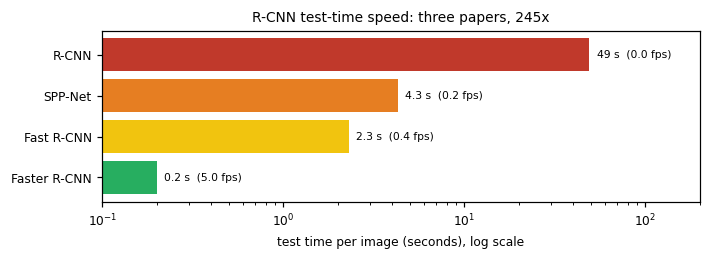

In [32]:
methods = ['R-CNN', 'SPP-Net', 'Fast R-CNN', 'Faster R-CNN']
speed = [49, 4.3, 2.3, 0.2]
fig, ax = plt.subplots(figsize=(6.5, 2.4))
b = ax.barh(np.arange(4), speed, color=['#c0392b', '#e67e22', '#f1c40f', '#27ae60'])
ax.set_yticks(np.arange(4)); ax.set_yticklabels(methods, fontsize=8); ax.invert_yaxis()
ax.set_xlabel('test time per image (seconds), log scale'); ax.set_xscale('log')
for i, v in enumerate(speed):
    ax.text(v * 1.1, i, '%g s  (%.1f fps)' % (v, 1 / v), va='center', fontsize=7)
ax.set_title('R-CNN test-time speed: three papers, 245x', fontsize=9)
ax.set_xlim(0.1, 200)
plt.tight_layout(); plt.show()

## 8. Evaluating object detectors

For classification we measure accuracy. For detection that will not do: a detector outputs a **variable
number** of boxes, each with a **score**, and a box can be right about the class but wrong about the
location. We need a metric that handles all of it.

The lecture's recipe:

1. Run the object detector on all test images (**with NMS**).
2. For each category, compute **Average Precision (AP) = area under the Precision vs Recall curve**:
   - For each detection, **from highest score to lowest**:
     - If it matches some ground-truth box with **IoU > 0.5**, mark it **positive** and **eliminate that GT**.
     - Otherwise mark it **negative**.
     - Plot a point on the PR curve.
   - AP = area under the PR curve.
3. **mAP** = mean of AP over categories.
4. For **COCO**: compute mAP at IoU thresholds $(0.5, 0.55, 0.60, \ldots, 0.95)$ and average them.

Three details that the recipe is quietly doing:

- **"Eliminate the GT"** is what punishes duplicates. The second box on an already-detected object cannot
  match anything, so it becomes a false positive. This is why NMS must run first.
- **Sorting by score** means AP measures the whole ranking, not one operating point. A detector that puts its
  correct boxes at the top scores well.
- **Missed objects** never appear in the detection list, but they are in the denominator of recall, so they
  drag the curve leftward. Nothing is swept under the rug.

$$\text{Precision} = \frac{TP}{TP + FP}, \qquad \text{Recall} = \frac{TP}{TP + FN} = \frac{TP}{\#\text{ground truth}}$$

We use the standard **all-point interpolation** for the area (VOC 2010 onwards, and what COCO approximates
with 101 sample points): the precision is first made monotonically non-increasing from the right,
$p_{\text{interp}}(r) = \max_{r' \ge r} p(r')$, then we take the area. Without this the curve is saw-toothed
and the area depends on noise.

In [33]:
def average_precision(dets, gts, iou_thr=0.5):
    '''Single-category AP.

    dets : list over images of (Ni, 5) tensors [x1, y1, x2, y2, score]
    gts  : list over images of (Mi, 4) tensors
    returns (ap, recall_curve, precision_curve)
    '''
    n_gt = int(sum(len(g) for g in gts))
    if n_gt == 0:
        return float('nan'), np.array([0.]), np.array([0.])

    # 1. pool every detection from every image and sort by score, highest first
    recs = [(float(d[j, 4]), i, d[j, :4]) for i, d in enumerate(dets) for j in range(len(d))]
    recs.sort(key=lambda r: -r[0])
    if not recs:
        return 0.0, np.array([0.]), np.array([0.])

    # 2. greedily match each detection to an unclaimed GT box
    matched = [np.zeros(len(g), bool) for g in gts]
    tp = np.zeros(len(recs)); fp = np.zeros(len(recs))
    for k, (s, i, box) in enumerate(recs):
        g = gts[i]
        if len(g) == 0:
            fp[k] = 1; continue
        ious = box_iou_scratch(box[None], g)[0].numpy()
        j = int(ious.argmax())                       # the best-overlapping GT for this detection
        if ious[j] > iou_thr and not matched[i][j]:
            tp[k] = 1; matched[i][j] = True          # positive, and this GT is now eliminated
        else:
            fp[k] = 1                                # missed, or a duplicate on an already-claimed GT

    # 3. running precision / recall down the ranked list
    tpc, fpc = np.cumsum(tp), np.cumsum(fp)
    rec = tpc / n_gt
    prec = tpc / np.maximum(tpc + fpc, 1e-12)

    # 4. all-point interpolated area under the PR curve
    mrec = np.concatenate(([0.], rec, [1.]))
    mpre = np.concatenate(([0.], prec, [0.]))
    for i in range(mpre.size - 1, 0, -1):
        mpre[i - 1] = max(mpre[i - 1], mpre[i])      # make precision non-increasing from the right
    idx = np.where(mrec[1:] != mrec[:-1])[0]         # only where recall actually changes
    ap = float(np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1]))
    return ap, rec, prec

### 8.1 Is our AP correct? Check it against values we work out by hand

A metric implementation that is silently wrong will happily report a beautiful number. So before we point
`average_precision` at the detector, we point it at three tiny cases whose answers we derive on paper.

**Case 1: two objects, detections ranked TP, FP, TP.**

| rank | outcome | cumulative TP | cumulative FP | precision | recall |
|---|---|---|---|---|---|
| 1 | TP on A | 1 | 0 | 1/1 = 1.00 | 1/2 = 0.5 |
| 2 | FP (empty space) | 1 | 1 | 1/2 = 0.50 | 1/2 = 0.5 |
| 3 | TP on B | 2 | 1 | 2/3 = 0.67 | 2/2 = 1.0 |

After making precision non-increasing from the right it becomes $1.00, 0.67, 0.67$. The area is the sum over
the two recall steps:

$$AP = \underbrace{(0.5 - 0)}_{\text{first step}} \times 1.00 + \underbrace{(1.0 - 0.5)}_{\text{second step}} \times 0.67 = 0.5 + \tfrac{1}{3} = \tfrac{5}{6} \approx 0.8333$$

**Case 2: one object, detections ranked FP, TP.** Precision is $0$ then $0.5$; the envelope makes it $0.5$
everywhere, and recall goes $0 \to 1$ in one step, so $AP = 1.0 \times 0.5 = \mathbf{0.5}$. Ranking the wrong
box first costs exactly half the score.

**Case 3: one object, two overlapping detections on it.** The first is a TP; the second cannot re-match the
eliminated GT, so it is a **duplicate FP**. Recall already reached 1.0 at rank 1 with precision 1.0, so
$AP = \mathbf{1.0}$: under the interpolated definition, duplicates *after* full recall do not reduce AP,
though they do dent precision at any fixed operating point. This is a real (and often surprising) property of
the metric, and it is why NMS matters for reasons beyond AP.

In [34]:
A_box = torch.tensor([[10., 10., 20., 20.]])       # object A
B_box = torch.tensor([[40., 40., 50., 50.]])       # object B
FAR = [0., 55., 8., 63.]                           # a box on empty background

case1 = ([torch.tensor([[10., 10., 20., 20., 0.9],          # TP on A
                        FAR + [0.8],                        # FP
                        [40., 40., 50., 50., 0.7]])],       # TP on B
         [torch.cat([A_box, B_box], 0)], 5 / 6)
case2 = ([torch.tensor([FAR + [0.9], [10., 10., 20., 20., 0.8]])], [A_box], 0.5)
case3 = ([torch.tensor([[10., 10., 20., 20., 0.9], [10.5, 10.5, 20.5, 20.5, 0.8]])], [A_box], 1.0)
case4 = ([torch.tensor([[10., 10., 20., 20., 0.9], [40., 40., 50., 50., 0.8]])],
         [torch.cat([A_box, B_box], 0)], 1.0)      # perfect detector

print('%-46s %10s %10s   %s' % ('hand-worked case', 'expected', 'ours', ''))
for name, (d, g, want) in [('1: TP, FP, TP on 2 objects', case1),
                           ('2: FP, TP on 1 object', case2),
                           ('3: TP + duplicate FP on 1 object', case3),
                           ('4: perfect detector, 2 objects', case4)]:
    got = average_precision(d, g, 0.5)[0]
    assert abs(got - want) < 1e-9, (name, got, want)
    print('%-46s %10.4f %10.4f   OK' % (name, want, got))
print('\naverage_precision reproduces every hand-computed value exactly.')

hand-worked case                                 expected       ours   
1: TP, FP, TP on 2 objects                         0.8333     0.8333   OK
2: FP, TP on 1 object                              0.5000     0.5000   OK
3: TP + duplicate FP on 1 object                   1.0000     1.0000   OK
4: perfect detector, 2 objects                     1.0000     1.0000   OK

average_precision reproduces every hand-computed value exactly.


### 8.2 The PR curve of our detector

Now we trust the metric, so we can point it at the Fast R-CNN we trained in section 5 and at the Faster
R-CNN (RPN proposals) from section 7.

AP@0.5 per class (Fast R-CNN, Selective-Search-like proposals):
   square     0.952
   circle     1.000
   triangle   1.000
   MEAN       0.984  <- mAP

mAP@0.5  Fast R-CNN  (85 proposals/img): 0.984
mAP@0.5  Faster R-CNN (22 proposals/img): 0.987
mAP@0.5  chance reference (random scores, unrefined boxes): 0.080

The detector is 12x above the chance reference.


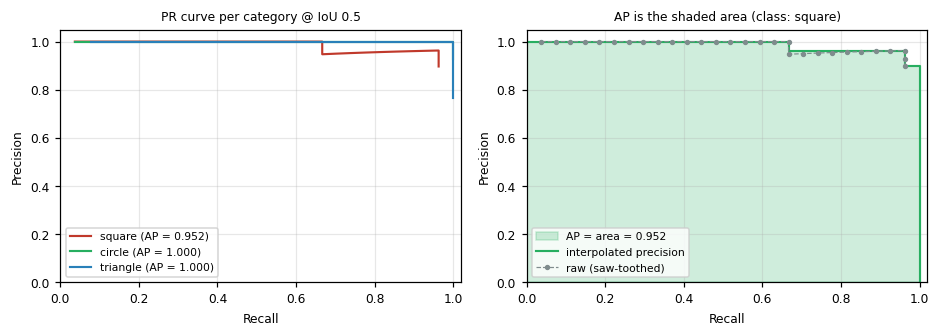

In [35]:
def eval_detector(dets, iou_thr=0.5):
    '''Returns per-class AP dict, mAP, and per-class PR curves.'''
    aps, curves = {}, {}
    for c in range(1, NUM_CLASSES):
        dd = [d[d[:, 5] == c][:, :5] for d in dets]
        gg = [te_boxes[i][te_labels[i] == c] for i in range(N_TEST)]
        if sum(len(g) for g in gg) == 0:
            continue
        ap, rec, prec = average_precision(dd, gg, iou_thr)
        aps[CLASS_NAMES[c]] = ap
        curves[CLASS_NAMES[c]] = (rec, prec)
    return aps, float(np.mean(list(aps.values()))), curves


aps_ss, mAP_ss, curves_ss = eval_detector(dets_ss, 0.5)
aps_rpn, mAP_rpn, _ = eval_detector(dets_rpn, 0.5)

# A reference point for "chance": the same proposals, but scored at random and never refined.
_r = np.random.default_rng(0)
rand_dets = []
for i in range(N_TEST):
    p = te_props[i]
    rand_dets.append(torch.cat([p, torch.tensor(_r.uniform(0, 1, (len(p), 1)), dtype=torch.float32),
                                torch.tensor(_r.integers(1, NUM_CLASSES, (len(p), 1)), dtype=torch.float32)], 1))
_, mAP_chance, _ = eval_detector(rand_dets, 0.5)

print('AP@0.5 per class (Fast R-CNN, Selective-Search-like proposals):')
for k, v in aps_ss.items():
    print('   %-10s %.3f' % (k, v))
print('   %-10s %.3f  <- mAP' % ('MEAN', mAP_ss))
print()
print('mAP@0.5  Fast R-CNN  (%.0f proposals/img): %.3f' % (np.mean([len(p) for p in te_props]), mAP_ss))
print('mAP@0.5  Faster R-CNN (%.0f proposals/img): %.3f' % (np.mean([len(p) for p in rpn_props]), mAP_rpn))
print('mAP@0.5  chance reference (random scores, unrefined boxes): %.3f' % mAP_chance)
assert mAP_ss > 0.7 and mAP_ss > 8 * mAP_chance, 'the detector should be far above chance'
print('\nThe detector is %.0fx above the chance reference.' % (mAP_ss / max(mAP_chance, 1e-6)))

fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.1))
for (name, (rec, prec)), c in zip(curves_ss.items(), ['#c0392b', '#27ae60', '#2980b9']):
    axes[0].plot(rec, prec, color=c, label='%s (AP = %.3f)' % (name, aps_ss[name]), lw=1.4)
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision'); axes[0].set_xlim(0, 1.02); axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=7, loc='lower left'); axes[0].grid(alpha=0.3)
axes[0].set_title('PR curve per category @ IoU 0.5', fontsize=8)

name = min(aps_ss, key=aps_ss.get)   # lowest-AP class, so the saw-tooth and its envelope are visible
rec, prec = curves_ss[name]
mrec = np.concatenate(([0.], rec, [1.])); mpre = np.concatenate(([0.], prec, [0.]))
for i in range(mpre.size - 1, 0, -1):
    mpre[i - 1] = max(mpre[i - 1], mpre[i])
axes[1].fill_between(mrec, 0, mpre, step='post', color='#27ae60', alpha=0.22, label='AP = area = %.3f' % aps_ss[name])
axes[1].step(mrec, mpre, where='post', color='#27ae60', lw=1.4, label='interpolated precision')
axes[1].plot(rec, prec, 'o--', color='#7f8c8d', ms=2.5, lw=0.8, label='raw (saw-toothed)')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].set_xlim(0, 1.02); axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=7, loc='lower left'); axes[1].grid(alpha=0.3)
axes[1].set_title('AP is the shaded area (class: %s)' % name, fontsize=8)
plt.tight_layout(); plt.show()

### 8.3 COCO-style mAP: averaging over IoU thresholds

`mAP@0.5` is a forgiving metric: a box that is "roughly there" passes. COCO therefore averages mAP over
IoU thresholds $0.5, 0.55, \ldots, 0.95$, which rewards **precise localisation**, not just detection.

The lecture's example numbers show the same shape we are about to measure:
mAP@0.5 = 0.77, mAP@0.55 = 0.71, mAP@0.60 = 0.65, ..., mAP@0.95 = 0.2, giving COCO mAP = 0.4.

Watch our curve fall the same way, and note **why** it falls:

- Our backbone has stride 4, so RoI pooling quantizes every RoI to a 4-pixel grid (section 5.2). Two
  proposals less than 4 px apart get **identical** pooled features, so the head literally cannot see the
  difference. On objects ~20 px wide, a 2 px error is already an IoU of about 0.8.
- So high-IoU performance is capped by the **feature stride and the RoI pooling quantization**, not by how
  long we train. Exercise 2 at the end asks you to verify this claim, and it is exactly the problem that
  Mask R-CNN's **RoIAlign** (Lecture 4) fixes by dropping the rounding and sampling bilinearly.

IoU thr :  0.50  0.55  0.60  0.65  0.70  0.75  0.80  0.85  0.90  0.95
mAP     : 0.984 0.971 0.971 0.912 0.829 0.445 0.303 0.066 0.012 0.006

COCO-style mAP@[0.5:0.05:0.95]
  Fast R-CNN   (Selective-Search-like proposals): 0.550
  Faster R-CNN (RPN proposals)                  : 0.534


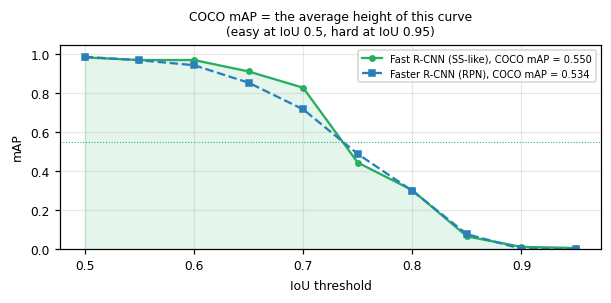

In [36]:
thrs = np.arange(0.5, 0.96, 0.05)
mAPs_ss = [eval_detector(dets_ss, t)[1] for t in thrs]
mAPs_rpn = [eval_detector(dets_rpn, t)[1] for t in thrs]
coco_ss, coco_rpn = float(np.mean(mAPs_ss)), float(np.mean(mAPs_rpn))

print('IoU thr : ' + ' '.join('%5.2f' % t for t in thrs))
print('mAP     : ' + ' '.join('%5.3f' % m for m in mAPs_ss))
print('\nCOCO-style mAP@[0.5:0.05:0.95]')
print('  Fast R-CNN   (Selective-Search-like proposals): %.3f' % coco_ss)
print('  Faster R-CNN (RPN proposals)                  : %.3f' % coco_rpn)

fig, ax = plt.subplots(figsize=(5.6, 2.8))
ax.plot(thrs, mAPs_ss, 'o-', color='#27ae60', ms=3.5, label='Fast R-CNN (SS-like), COCO mAP = %.3f' % coco_ss)
ax.plot(thrs, mAPs_rpn, 's--', color='#2980b9', ms=3.5, label='Faster R-CNN (RPN), COCO mAP = %.3f' % coco_rpn)
ax.axhline(coco_ss, color='#27ae60', lw=0.7, ls=':')
ax.fill_between(thrs, 0, mAPs_ss, color='#27ae60', alpha=0.12)
ax.set_xlabel('IoU threshold'); ax.set_ylabel('mAP'); ax.set_ylim(0, 1.05)
ax.legend(fontsize=6.5); ax.grid(alpha=0.3)
ax.set_title('COCO mAP = the average height of this curve\n(easy at IoU 0.5, hard at IoU 0.95)', fontsize=8)
plt.tight_layout(); plt.show()

### 8.4 Interactive: the IoU threshold and the operating point

- **`iou_thr`** changes what counts as a match, so it **recomputes the whole PR curve and the AP**. This is
  the "how precise must a box be?" knob.
- **`score_thr`** does *not* change AP at all. AP integrates over every threshold. What `score_thr` picks is
  the **operating point** you would actually deploy (the black dot): raise it for precision, lower it for
  recall. Watch the dot slide along a curve that does not move.

That distinction (a **curve** describes the detector, a **point** describes your deployment choice) is the
single most useful thing to take away from this section.

In [37]:
_all_dets_ss = dets_ss


def pr_demo(iou_thr=0.5, score_thr=0.5, category='circle'):
    c = CLASS_NAMES.index(category)
    dd = [d[d[:, 5] == c][:, :5] for d in _all_dets_ss]
    gg = [te_boxes[i][te_labels[i] == c] for i in range(N_TEST)]
    ap, rec, prec = average_precision(dd, gg, iou_thr)

    mrec = np.concatenate(([0.], rec, [1.])); mpre = np.concatenate(([0.], prec, [0.]))
    for i in range(mpre.size - 1, 0, -1):
        mpre[i - 1] = max(mpre[i - 1], mpre[i])

    # operating point: keep only detections above score_thr
    scores = np.array(sorted([float(d[j, 4]) for d in dd for j in range(len(d))], reverse=True))
    n_keep = int((scores > score_thr).sum())
    op_r = rec[n_keep - 1] if n_keep > 0 else 0.0
    op_p = prec[n_keep - 1] if n_keep > 0 else 1.0
    n_gt = sum(len(g) for g in gg)
    tp_op = op_r * n_gt

    fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.0))
    axes[0].fill_between(mrec, 0, mpre, step='post', color='#27ae60', alpha=0.22)
    axes[0].step(mrec, mpre, where='post', color='#27ae60', lw=1.4)
    axes[0].plot(rec, prec, '--', color='#7f8c8d', lw=0.8)
    axes[0].plot([op_r], [op_p], 'ko', ms=7, label='operating point (score > %.2f)' % score_thr)
    axes[0].set_xlim(0, 1.02); axes[0].set_ylim(0, 1.05)
    axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision'); axes[0].legend(fontsize=6.5, loc='lower left')
    axes[0].grid(alpha=0.3)
    axes[0].set_title('%s | IoU thr %.2f | AP = %.3f (shaded)' % (category, iou_thr, ap), fontsize=8)

    axes[1].bar(['TP', 'FP', 'FN'], [tp_op, n_keep - tp_op, n_gt - tp_op],
                color=['#27ae60', '#c0392b', '#95a5a6'])
    axes[1].set_title('at the operating point: %d detections kept, %d ground-truth objects\n'
                      'precision %.2f | recall %.2f' % (n_keep, n_gt, op_p, op_r), fontsize=8)
    axes[1].set_ylabel('count')
    plt.tight_layout(); plt.show()
    print('AP depends on iou_thr but NOT on score_thr (drag score_thr and watch AP stay put).')


widgets.interact(pr_demo,
                 iou_thr=widgets.FloatSlider(min=0.3, max=0.9, step=0.05, value=0.5, description='IoU thr', continuous_update=False),
                 score_thr=widgets.FloatSlider(min=0.02, max=0.98, step=0.02, value=0.5, description='score thr', continuous_update=False),
                 category=widgets.Dropdown(options=CLASS_NAMES[1:], value='circle', description='category'));

interactive(children=(FloatSlider(value=0.5, continuous_update=False, description='IoU thr', max=0.9, min=0.3,…

### 8.5 Now that we have a metric: what does $\lambda$ actually do?

We deferred this in 5.4, because **you cannot judge a loss without a metric**. $\lambda$ balances the two
terms of

$$L = L_{\text{cls}} + \lambda [u \ge 1] L_{\text{loc}}$$

We retrain the detector from the same seed at several $\lambda$ and evaluate each one properly. Predictions:

- $\lambda = 0$: the box regressor gets **no gradient at all**. The detector still classifies, but its boxes
  stay exactly where the proposals were, so AP should collapse.
- Large $\lambda$: localisation dominates and classification is starved, so $L_{cls}$ should creep up.

In [38]:
LAMBDAS = [0.0, 0.25, 1.0, 4.0]
sweep = {}
print('retraining at each lambda (same seed, 600 steps each)...')
t0 = time.perf_counter()
for lam in LAMBDAS:
    if lam == 1.0:
        b_, h_, hi_ = bb, head, hist                       # reuse the model from section 5.7
    else:
        b_, h_, hi_ = train_fast_rcnn(lam=lam, steps=600, seed=0, log_every=0)
    d_ = detect(b_, h_, te_imgs, te_props)
    sweep[lam] = dict(hist=hi_,
                      mAP50=eval_detector(d_, 0.5)[1],
                      mAP75=eval_detector(d_, 0.75)[1],
                      dets=d_)
    print('  lambda %5.2f -> mAP@0.5 %.3f | mAP@0.75 %.3f | final L_cls %.4f'
          % (lam, sweep[lam]['mAP50'], sweep[lam]['mAP75'], hi_[-50:, 1].mean()))
print('sweep done in %.1f s' % (time.perf_counter() - t0))
assert sweep[0.0]['mAP50'] < 0.5 < sweep[1.0]['mAP50'], 'lambda=0 must cripple localisation'
print('\nConfirmed: with lambda = 0 the boxes never move and mAP collapses from %.3f to %.3f.'
      % (sweep[1.0]['mAP50'], sweep[0.0]['mAP50']))

retraining at each lambda (same seed, 600 steps each)...


  lambda  0.00 -> mAP@0.5 0.141 | mAP@0.75 0.000 | final L_cls 0.1317


  lambda  0.25 -> mAP@0.5 0.986 | mAP@0.75 0.475 | final L_cls 0.1165
  lambda  1.00 -> mAP@0.5 0.984 | mAP@0.75 0.445 | final L_cls 0.1366


  lambda  4.00 -> mAP@0.5 1.000 | mAP@0.75 0.513 | final L_cls 0.1533
sweep done in 6.9 s

Confirmed: with lambda = 0 the boxes never move and mAP collapses from 0.984 to 0.141.


**Interactive:** step through $\lambda$. The right panel shows the detections: at $\lambda = 0$ they are
literally the raw proposals, ragged and offset, because nothing ever taught them to move.

In [39]:
def lambda_demo(lam=1.0):
    s = sweep[lam]
    hi = s['hist']
    k = 15
    sm = lambda a: np.convolve(a, np.ones(k) / k, mode='valid')

    fig = plt.figure(figsize=(11, 2.8))
    ax1 = fig.add_subplot(1, 4, 1)
    ax1.plot(np.arange(k - 1, len(hi)), sm(hi[:, 1]), color='#c0392b')
    ax1.set_title(r'$L_{cls}$ (final %.3f)' % hi[-50:, 1].mean(), fontsize=8); ax1.grid(alpha=0.3); ax1.set_xlabel('step')
    ax2 = fig.add_subplot(1, 4, 2)
    ax2.plot(np.arange(k - 1, len(hi)), sm(hi[:, 2]), color='#27ae60')
    ax2.set_title(r'$L_{loc}$ (final %.4f)' % hi[-50:, 2].mean(), fontsize=8); ax2.grid(alpha=0.3); ax2.set_xlabel('step')

    ax3 = fig.add_subplot(1, 4, 3)
    xs = np.arange(len(LAMBDAS))
    ax3.bar(xs - 0.2, [sweep[l]['mAP50'] for l in LAMBDAS], 0.4, color='#2980b9', label='mAP@0.5')
    ax3.bar(xs + 0.2, [sweep[l]['mAP75'] for l in LAMBDAS], 0.4, color='#8e44ad', label='mAP@0.75')
    ax3.axvline(LAMBDAS.index(lam), color='k', lw=0.8, ls='--')
    ax3.set_xticks(xs); ax3.set_xticklabels([str(l) for l in LAMBDAS], fontsize=7)
    ax3.set_xlabel(r'$\lambda$'); ax3.set_ylim(0, 1.05); ax3.legend(fontsize=6); ax3.set_title('accuracy vs lambda', fontsize=8)

    ax4 = fig.add_subplot(1, 4, 4)
    d = s['dets'][2]; d = d[d[:, 4] > 0.5]
    show_img(ax4, te_imgs[2])
    draw_boxes(ax4, te_boxes[2], color='k', lw=1.5, ls='--')
    draw_boxes(ax4, d[:, :4], color='#e74c3c', lw=1.2)
    ax4.set_title('detections at $\\lambda$ = %g' % lam, fontsize=8)
    fig.suptitle(r'$\lambda$ = %g   |   mAP@0.5 = %.3f   |   mAP@0.75 = %.3f' % (lam, s['mAP50'], s['mAP75']),
                 y=1.05, fontsize=9)
    plt.tight_layout(); plt.show()


widgets.interact(lambda_demo,
                 lam=widgets.SelectionSlider(options=LAMBDAS, value=1.0, description='lambda', continuous_update=False));

interactive(children=(SelectionSlider(continuous_update=False, description='lambda', index=2, options=(0.0, 0.…

## Key takeaways: three papers, one idea repeated

Each row fixes the bottleneck the row above it exposed.

| | **R-CNN** (CVPR 2014) | **Fast R-CNN** (ICCV 2015) | **Faster R-CNN** (NeurIPS 2015) |
|---|---|---|---|
| **Proposals** | Selective Search (~2000, CPU) | Selective Search (~2000, CPU) | **RPN** (learned, on the GPU, shares the backbone) |
| **CNN passes / image** | **~2000** (one per warped crop) | **1** (shared feature map) | **1** (shared by RPN *and* detector) |
| **Fixed-size features via** | warping the image crop to 227x227 | **RoI projection + RoI pooling** | RoI projection + RoI pooling |
| **Classifier** | class-specific **SVMs** (offline) | **softmax** head, in-network | softmax head, in-network |
| **Box regression** | separate ridge regressors, **L2** | in-network head, **smooth L1** | smooth L1, in both RPN and head |
| **Training** | **3 stages**, features cached to disk (100s of GB) | **1 stage**, one multi-task loss, end to end | 4-step alternating (or joint), end to end |
| **Test time / image** | **49 s** | **2.3 s** (0.32 s net + ~2 s proposals) | **0.2 s** |
| **The bottleneck it leaves** | 2000 redundant CNN passes | Selective Search (~86% of test time) | (dense one-stage detectors chase this: Lecture 3) |

**The one-line story:** *R-CNN* proved CNN features win at detection but recomputed them 2000 times.
*Fast R-CNN* computed them once and cropped the **feature map** instead of the image, which made the
hand-designed proposals the bottleneck. *Faster R-CNN* learned the proposals too, and the detector became
one network trained by one loss with nothing hand-designed left in the loop.

**What we verified in this notebook, rather than asserted**

- `roi_pool_scratch` reproduces `torchvision.ops.roi_pool` exactly (200 RoIs, 6 output sizes), including the
  half-away-from-zero rounding rule.
- `box_iou_scratch`, `nms_scratch` and `smooth_l1_scratch` match their torchvision / PyTorch references, and
  `decode(encode(P, G)) == G`.
- Sharing the backbone is measurably faster than per-crop CNN passes, and the gap **grows with the proposal
  count**, exactly as the pixel-counting argument predicts.
- `average_precision` reproduces four hand-computed values exactly.
- The detector learns (mAP@0.5 far above the chance reference), and $\lambda = 0$ demonstrably breaks
  localisation.

**Coming in Lecture 3:** one-stage detectors (YOLO, SSD, FPN, RetinaNet), which delete the proposal stage
altogether and predict densely, trading a little accuracy for a lot of speed.

## Exercises

1. **The homework, formally.** The lecture asks: *why is smooth L1 less sensitive to outliers than L2?*
   Using the gradient plot in 5.4, write the answer in two sentences. Then extend it: what goes wrong if you
   use **pure L1** everywhere instead (look at the gradient at $x = 0$, and think about what happens to a
   residual that is already tiny)? Verify with the `beta` slider by pushing beta towards 0.

2. **Prove the quantization claim.** Section 8.3 claims that high-IoU performance is capped by RoI pooling's
   quantization at stride 4, not by training. Test it: remove the **second** `nn.MaxPool2d(2)` from
   `Backbone` and set `STRIDE = 2`, then retrain and recompute mAP@0.75.
   *(We measured mAP@0.75 rising from 0.445 to 0.897 with everything else unchanged. As a control, training
   the stride-4 model twice as long with a wider head moved it only from 0.445 to 0.461, so the ceiling is
   the quantization, not the optimisation.)* For the real fix, read up on **RoIAlign** in Mask R-CNN.

3. **Break the anchors.** In the 7.1 widget, set `# scales = 1` and `base scale = 6`, and read the best-case
   recall. Then explain why the RPN's *ceiling* drops even though the RPN itself is unchanged, and relate
   this to why Faster R-CNN uses 3 scales x 3 aspect ratios. What would you choose for a dataset of very tall,
   thin pedestrians?

4. **Make the metric lie.** Take the trained detector and emit **every** proposal as a detection with a tiny
   score (set `score_thr = 0.0` in `detect`). Does mAP@0.5 go up, down, or stay put? Explain using the fact
   that AP integrates over the whole ranking, and say why this trick would still be a terrible idea in a
   deployed system.